In [1]:
# Ran the IPython code as instructed

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# Imported the packages I would need for the data cleaning and analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline
%matplotlib ipympl
import seaborn as sns
import ipywidgets as widgets

from dash import Dash, html, dcc, callback, Input, Output, dash_table
import plotly.express as px
import plotly.graph_objects as go
import dash_bootstrap_components as dbc

In [3]:
#Created a team name map dictionary to account for team name changes over the years that are included in the data set

team_name_map = {
    'Washington Football Team': 'Washington Commanders',
    'Washington Redskins': 'Washington Commanders',
    'Oakland Raiders': 'Las Vegas Raiders',
    'San Diego Chargers': 'Los Angeles Chargers',
    'St. Louis Rams': 'Los Angeles Rams',
}

In [4]:
#Started with NFL offensive stats, renamed a column 'PF': 'Pts', added two columns, stripped white space, and eliminated an unnamed column
#that was included from the CSV. Added in Off_ at the beginning of each column name, so when the data was merged with defensive stats 
#Offensive and defensive columns would be easier to identify
#Also dealt with the double row header using (header=[0,1])

nfl_2025_team_offensive_stats = pd.read_csv("Team_Offensive_Stats_2025.csv", header=[0,1])
nfl_2025_team_offensive_stats.rename(columns={'PF': 'Pts'}, inplace=True)
nfl_2025_team_offensive_stats ["Stat Type"] = "Offensive"
nfl_2025_team_offensive_stats ["Season"] = "2025"
nfl_2025_team_offensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2025_team_offensive_stats.columns
]
nfl_2025_team_offensive_stats.columns = [f"off_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2025_team_offensive_stats.columns]

In [5]:
#Imported team records for the 2025 season, stripped out white space and removed footnotes from team names

nfl_2025_team_records = pd.read_csv("NFL_Team_Records_2025.csv")
nfl_2025_team_records.columns = nfl_2025_team_records.columns.str.strip()
nfl_2025_team_records['Tm'] = nfl_2025_team_records['Tm'].str.replace(r'[*#+]', '', regex=True).str.strip()

In [6]:
#Combined the 2025 offensive states with the team records from 2025 using a left-hand merge on Tm

nfl_2025_team_stats_records_combined = nfl_2025_team_records.merge(nfl_2025_team_offensive_stats, on="Tm", how="left")

In [7]:
#Follow the same steps as with the 2025 season data above. 

nfl_2024_team_offensive_stats = pd.read_csv("Team_Offensive_Stats_2024.csv", header=[0,1])
nfl_2024_team_offensive_stats ["Stat Type"] = "Offensive"
nfl_2024_team_offensive_stats ["Season"] = "2024"
nfl_2024_team_offensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2024_team_offensive_stats.columns
]
nfl_2024_team_offensive_stats.columns = [f"off_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2024_team_offensive_stats.columns]
nfl_2024_team_offensive_stats = nfl_2024_team_offensive_stats.set_index("Tm")

In [8]:
#Follow the same steps as with the 2025 season data above. 

nfl_2024_team_records = pd.read_csv("NFL_Team_Records_2024.csv")
nfl_2024_team_records.columns = nfl_2024_team_records.columns.str.strip()
nfl_2024_team_records['Tm'] = nfl_2024_team_records['Tm'].str.replace(r'[*#+]', '', regex=True).str.strip()

In [9]:
#Follow the same steps as with the 2025 season data above. 

nfl_2024_team_stats_records_combined = nfl_2024_team_records.merge(nfl_2024_team_offensive_stats, on="Tm", how="left")

In [10]:
#Follow the same steps as with the 2025 season data above. 

nfl_2023_team_offensive_stats = pd.read_csv("Team_Offensive_Stats_2023.csv", header=[0,1])
nfl_2023_team_offensive_stats ["Stat Type"] = "Offensive"
nfl_2023_team_offensive_stats ["Season"] = "2023"
nfl_2023_team_offensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2023_team_offensive_stats.columns
]
nfl_2023_team_offensive_stats.columns = [f"off_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2023_team_offensive_stats.columns]
nfl_2023_team_offensive_stats = nfl_2023_team_offensive_stats.set_index("Tm")

In [11]:
#Follow the same steps as with the 2025 season data above. 

nfl_2023_team_records = pd.read_csv("NFL_Team_Records_2023.csv")
nfl_2023_team_records.columns = nfl_2023_team_records.columns.str.strip()
nfl_2023_team_records['Tm'] = nfl_2023_team_records['Tm'].str.replace(r'[*#+]', '', regex=True).str.strip()

In [12]:
#Follow the same steps as with the 2025 season data above. 

nfl_2023_team_stats_records_combined = nfl_2023_team_records.merge(nfl_2023_team_offensive_stats, on="Tm", how="left")

In [13]:
#Follow the same steps as with the 2025 season data above. 

nfl_2022_team_offensive_stats = pd.read_csv("Team_Offensive_Stats_2022.csv", header=[0,1])
nfl_2022_team_offensive_stats ["Stat Type"] = "Offensive"
nfl_2022_team_offensive_stats ["Season"] = "2022"
nfl_2022_team_offensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2022_team_offensive_stats.columns
]
nfl_2022_team_offensive_stats.columns = [f"off_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2022_team_offensive_stats.columns]
nfl_2022_team_offensive_stats = nfl_2022_team_offensive_stats.set_index("Tm")

In [14]:
#Follow the same steps as with the 2025 season data above. 

nfl_2022_team_records = pd.read_csv("NFL_Team_Records_2022.csv")
nfl_2022_team_records.columns = nfl_2022_team_records.columns.str.strip()
nfl_2022_team_records['Tm'] = nfl_2022_team_records['Tm'].str.replace(r'[*#+]', '', regex=True).str.strip()

In [15]:
#Follow the same steps as with the 2025 season data above. 

nfl_2022_team_stats_records_combined = nfl_2022_team_records.merge(nfl_2022_team_offensive_stats, on="Tm", how="left")

In [16]:
#Follow the same steps as with the 2025 season data above. 

nfl_2021_team_offensive_stats = pd.read_csv("Team_Offensive_Stats_2021.csv", header=[0,1])
nfl_2021_team_offensive_stats ["Stat Type"] = "Offensive"
nfl_2021_team_offensive_stats ["Season"] = "2021"
nfl_2021_team_offensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2021_team_offensive_stats.columns
]
nfl_2021_team_offensive_stats.columns = [f"off_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2021_team_offensive_stats.columns]
nfl_2021_team_offensive_stats = nfl_2021_team_offensive_stats.set_index("Tm")

In [17]:
#Follow the same steps as with the 2025 season data above. 

nfl_2021_team_records = pd.read_csv("NFL_Team_Records_2021.csv")
nfl_2021_team_records.columns = nfl_2021_team_records.columns.str.strip()
nfl_2021_team_records['Tm'] = nfl_2021_team_records['Tm'].str.replace(r'[*#+]', '', regex=True).str.strip()

In [18]:
#Follow the same steps as with the 2025 season data above. 

nfl_2021_team_stats_records_combined = nfl_2021_team_records.merge(nfl_2021_team_offensive_stats, on="Tm", how="left")

In [19]:
#Used a for loop and a lambda function, and the team mapping variable from above, to correctly match all team names in the data set

for df in [nfl_2025_team_offensive_stats, nfl_2024_team_offensive_stats, 
           nfl_2023_team_offensive_stats, nfl_2022_team_offensive_stats, 
           nfl_2021_team_offensive_stats, nfl_2025_team_records, nfl_2024_team_records,
           nfl_2023_team_records, nfl_2022_team_records, nfl_2021_team_records]:
    df.index = df.index.map(lambda x: team_name_map.get(x, x))

In [20]:
#Used pd.concat to create a new DataFrame. Set the index to the team name and dropped the "Rk" column that was not needed from when the CSVs
#were read in. 

nfl_offensive_team_stats_combined = pd.concat([nfl_2025_team_stats_records_combined, nfl_2024_team_stats_records_combined,
                                              nfl_2023_team_stats_records_combined, nfl_2022_team_stats_records_combined,
                                              nfl_2021_team_stats_records_combined])
nfl_offensive_team_stats_combined = nfl_offensive_team_stats_combined.set_index ("Tm")
nfl_offensive_team_stats_combined = nfl_offensive_team_stats_combined.drop(columns=['Rk'])

In [21]:
#Created a dictionary to rename all of the columns so that when combined with defensive stats later, 
#The stats would be easily identified as either offensive or defensive

column_rename = {
    'off_Pts' : 'Off Pts',
    'off_Yds': 'Total Yards',
    'off_Tot Yds & TO_Ply': 'Off Plays',
    'off_Tot Yds & TO_Y/P': 'Yds/Play',
    'off_Tot Yds & TO_TO': 'Turnovers',
    'off_FL': 'Fumbles Lost',
    'off_1stD': 'Total 1st Downs',
    'off_Passing_Cmp': 'Pass Comp',
    'off_Passing_Att': 'Pass Att',
    'off_Passing_Yds': 'Pass Yds',
    'off_Passing_TD': 'Pass TD',
    'off_Passing_Int': 'Pass INT',
    'off_Passing_NY/A': 'Pass NY/A',
    'off_Passing_1stD': 'Pass 1st Downs',
    'off_Rushing_Att': 'Rush Att',
    'off_Rushing_Yds': 'Rush Yds',
    'off_Rushing_TD': 'Rush TD',
    'off_Rushing_Y/A': 'Rush Y/A',
    'off_Rushing_1stD': 'Rush 1st Downs',
    'off_Penalties_Pen': 'Penalties',
    'off_Penalties_Yds': 'Penalty Yds',
    'off_Penalties_1stPy': 'Penalty 1st Downs',
    'off_Sc%': 'Scoring %',
    'off_TO%': 'Turnover %',
    'off_EXP': 'Off Expected Pts',
}

nfl_offensive_team_stats_combined = nfl_offensive_team_stats_combined.rename(columns=column_rename)


In [22]:
nfl_offensive_team_stats_combined.columns.tolist()

['W',
 'L',
 'T',
 'W-L%',
 'PF',
 'PA',
 'PD',
 'MoV',
 'SoS',
 'SRS',
 'OSRS',
 'DSRS',
 'G',
 'Off Pts',
 'Total Yards',
 'Off Plays',
 'Yds/Play',
 'Turnovers',
 'Fumbles Lost',
 'Total 1st Downs',
 'Pass Comp',
 'Pass Att',
 'Pass Yds',
 'Pass TD',
 'Pass INT',
 'Pass NY/A',
 'Pass 1st Downs',
 'Rush Att',
 'Rush Yds',
 'Rush TD',
 'Rush Y/A',
 'Rush 1st Downs',
 'Penalties',
 'Penalty Yds',
 'Penalty 1st Downs',
 'Scoring %',
 'Turnover %',
 'Off Expected Pts',
 'off_Stat Type',
 'off_Season']

In [23]:
#Created subgroups to look at the predictive value of each offensive stat
#Subgroup helps to decrease the number of variables that are being viewed simultaneously 

# Totals subset
predictors_totals = nfl_offensive_team_stats_combined[['W-L%', 'Off Pts', 'Total Yards', 'Off Plays', 'Yds/Play',
                         'Turnovers', 'Fumbles Lost', 'Total 1st Downs',
                         'Scoring %', 'Turnover %', 'Off Expected Pts']]

# Passing subset
predictors_passing = nfl_offensive_team_stats_combined[['W-L%', 'Pass Comp', 'Pass Att', 'Pass Yds',
                          'Pass TD', 'Pass INT', 'Pass NY/A', 'Pass 1st Downs']]

# Rushing subset
predictors_rushing = nfl_offensive_team_stats_combined[['W-L%', 'Rush Att', 'Rush Yds', 'Rush TD',
                          'Rush Y/A', 'Rush 1st Downs']]

# Penalties subset
predictors_penalties = nfl_offensive_team_stats_combined[['W-L%', 'Penalties', 'Penalty Yds', 'Penalty 1st Downs']]
                                                                                           


In [24]:
#sns.pairplot(predictors_totals, diag_kind="kde", kind = "reg", plot_kws={"line_kws":{'color': "red"}})

In [25]:
# Correlation of all columns with win percentage
#corr = nfl_offensive_team_stats_combined_predictors.corr()['W-L%'].drop('W-L%').sort_values(ascending=False)

# Plot
#plt.figure(figsize=(12, 8))
#sns.heatmap(corr.to_frame(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
#plt.title('Offensive Stats Correlation with Win%')
#plt.tight_layout()
#plt.show()
#plt.close()

In [26]:
#Reset the index, had to deal with name inconsistencies - again was mapping team name values to the keys in the dictionary above, converted the win % 

nfl_offensive_team_stats_combined = nfl_offensive_team_stats_combined.reset_index()
nfl_offensive_team_stats_combined['Tm'] = nfl_offensive_team_stats_combined['Tm'].replace(team_name_map)
nfl_offensive_team_stats_combined ['W-L%'] = round((nfl_offensive_team_stats_combined ['W-L%']*100),1)
nfl_offensive_team_stats_combined

,Tm,W,L,T,W-L%,PF,PA,PD,MoV,SoS,...,Rush Y/A,Rush 1st Downs,Penalties,Penalty Yds,Penalty 1st Downs,Scoring %,Turnover %,Off Expected Pts,off_Stat Type,off_Season
0,New England Patriots,14,3,0.0,82.4,490,320,170,10.0,-4.5,...,4.4,128,99,854,26,46.0,9.2,195.86,Offensive,2025
1,Buffalo Bills,12,5,0.0,70.6,481,365,116,6.8,-2.3,...,5.0,146,101,848,32,44.8,10.3,186.79,Offensive,2025
2,Miami Dolphins,7,10,0.0,41.2,347,424,-77,-4.5,-1.8,...,4.7,104,101,811,13,36.6,13.1,17.51,Offensive,2025
3,New York Jets,3,14,0.0,17.6,300,503,-203,-11.9,-0.6,...,4.6,115,110,909,21,29.8,11.6,-104.52,Offensive,2025
4,Pittsburgh Steelers,10,7,0.0,58.8,397,387,10,0.6,-0.5,...,4.3,109,101,803,32,39.0,7.9,63.15,Offensive,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Carolina Panthers,5,12,0.0,29.4,304,404,-100,-5.9,0.4,...,4.0,118,107,864,30,29.2,14.9,-92.10,Offensive,2021
156,Los Angeles Rams,12,5,0.0,70.6,460,372,88,5.2,0.1,...,4.0,99,76,637,23,45.9,12.2,146.41,Offensive,2021
157,Arizona Cardinals,11,6,0.0,64.7,449,366,83,4.9,0.3,...,4.2,127,114,990,26,44.7,7.8,137.75,Offensive,2021
158,San Francisco 49ers,10,7,0.0,58.8,427,365,62,3.6,0.1,...,4.3,130,102,1066,31,41.2,11.5,135.41,Offensive,2021


In [27]:
#Created a dictionary for the different statistical groupings by type 

stat_groups = {
    'All': None,
    'Totals': ['Off Pts', 'Total Yards', 'Off Plays', 'Yds/Play',
               'Turnovers', 'Fumbles Lost', 'Total 1st Downs',
               'Scoring %', 'Turnover %', 'Off Expected Pts'],
    'Passing': ['Pass Comp', 'Pass Att', 'Pass Yds', 'Pass TD',
                'Pass INT', 'Pass NY/A', 'Pass 1st Downs'],
    'Rushing': ['Rush Att', 'Rush Yds', 'Rush TD', 'Rush Y/A', 'Rush 1st Downs'],
    'Penalties': ['Penalties', 'Penalty Yds', 'Penalty 1st Downs'],
}

In [54]:
#This is where we started to get into the visualization of the data 
#The first several visuals are heat maps looking at the correlation between win percentage and the different offensive statistics variables
#from the data set. 
#We added a few extra features, such as dropdown menu bars to change between seasons, stat type, and specific stats within the stat type
#Created a heatmap plot 
#Left in Wins and Losses to show that the visual was working correctly - wins were a perfect positive correlation (1.0), and losses had a perfect negative correlation -1.0 


def get_stat_options(stat_type):
    if stat_groups[stat_type] is None:
        return ['All'] + [c for v in stat_groups.values() if v is not None for c in v]
    return ['All'] + stat_groups[stat_type]

# --- Dropdowns ---
seasons_sorted = sorted(nfl_offensive_team_stats_combined['off_Season'].unique())

dropdown_season = widgets.Dropdown(
    options=seasons_sorted, value=seasons_sorted[-1], description='Season:')
dropdown_type = widgets.Dropdown(
    options=['All', 'Totals', 'Passing', 'Rushing', 'Penalties'], value='All', description='Stat Type:')
dropdown_stat = widgets.Dropdown(
    options=get_stat_options('All'), value='All', description='Stat:')

output = widgets.Output()

# --- Plot function ---
def plot_heatmap():
    season = dropdown_season.value
    stat_type = dropdown_type.value
    specific_stat = dropdown_stat.value

    with output:
        output.clear_output(wait=True)
        plt.close('all')

        season_df = nfl_offensive_team_stats_combined[
            nfl_offensive_team_stats_combined['off_Season'] == season
        ].copy()

        # Filter to stat group
        if stat_groups[stat_type] is not None:
            cols = ['W-L%'] + [c for c in stat_groups[stat_type] if c in season_df.columns]
            season_df = season_df[cols]
        else:
            season_df = season_df.select_dtypes(include='number').drop(
                columns=['off_Season'], errors='ignore')

        # Force numeric
        season_df = season_df.apply(pd.to_numeric, errors='coerce')

        if specific_stat != 'All' and specific_stat in season_df.columns:
            mask = season_df[[specific_stat, 'W-L%']].dropna()
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.scatter(mask[specific_stat], mask['W-L%'], alpha=0.7, edgecolors='black')
            corr_val = mask[specific_stat].corr(mask['W-L%'])
            if len(mask) > 1:
                z = np.polyfit(mask[specific_stat], mask['W-L%'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(mask[specific_stat].min(), mask[specific_stat].max(), 100)
                ax.plot(x_line, p(x_line), 'r--', alpha=0.8)
            ax.set_xlabel(specific_stat, fontsize=12)
            ax.set_ylabel('Win %', fontsize=12)
            ax.set_title(f'{season} - {specific_stat} vs Win%  (r = {corr_val:.3f})', fontsize=14)
        else:
            corr = season_df.corr(numeric_only=True)['W-L%'].drop('W-L%').dropna().sort_values(ascending=False)
            if corr.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                ax.text(0.5, 0.5, 'No correlation data available', ha='center', va='center', fontsize=14)
                ax.set_axis_off()
            else:
                fig, ax = plt.subplots(figsize=(10, max(6, len(corr) * 0.5)))
                sns.heatmap(corr.to_frame(name=f'{season} {stat_type}'), annot=True, cmap='RdYlGn',
                            center=0, fmt='.2f', ax=ax)
                ax.set_title(f'{season} - {stat_type} Correlation with Win%', fontsize=14)

        plt.tight_layout()
        plt.show()

# --- Event handlers ---
def on_type_change(change):
    dropdown_stat.unobserve(on_stat_change, names='value')
    dropdown_stat.options = get_stat_options(change['new'])
    dropdown_stat.value = 'All'
    dropdown_stat.observe(on_stat_change, names='value')
    plot_heatmap()

def on_season_change(change):
    plot_heatmap()

def on_stat_change(change):
    plot_heatmap()

dropdown_season.observe(on_season_change, names='value')
dropdown_type.observe(on_type_change, names='value')
dropdown_stat.observe(on_stat_change, names='value')

# Layout
controls = widgets.HBox([dropdown_season, dropdown_type, dropdown_stat])
display(widgets.VBox([controls, output]))

# Initial plot
plot_heatmap()

In [57]:
#Next, we wanted to take the visuals a step further and make the different variables truly interactive by creating a dashboard using Dash
#We were able to visualize a 5-tab dashboard that would allow the end user to fully immerse themselves in the data set and view the heatmap correlations
#specific stats vs. win %, team comparisons, trend analysis, and finally a raw data table to view each of the stats that we are being utilized to create the 
#visualizations


df = nfl_offensive_team_stats_combined.copy()
df = df.reset_index()

# Adjust these if your column names differ
TEAM_COL = 'Tm'          # <-- change if needed
SEASON_COL = 'off_Season'

nfl_teams = sorted(df[TEAM_COL].unique().tolist())
seasons = sorted(df[SEASON_COL].unique().tolist())

# ============= STAT GROUPS =============

stat_groups = {
    'All': None,
    'Totals': ['Off Pts', 'Total Yards', 'Off Plays', 'Yds/Play',
               'Turnovers', 'Fumbles Lost', 'Total 1st Downs',
               'Scoring %', 'Turnover %', 'Off Expected Pts'],
    'Passing': ['Pass Comp', 'Pass Att', 'Pass Yds', 'Pass TD',
                'Pass INT', 'Pass NY/A', 'Pass 1st Downs'],
    'Rushing': ['Rush Att', 'Rush Yds', 'Rush TD', 'Rush Y/A', 'Rush 1st Downs'],
    'Penalties': ['Penalties', 'Penalty Yds', 'Penalty 1st Downs'],
}

def get_stat_options(stat_type):
    if stat_groups[stat_type] is None:
        return ['All'] + [c for v in stat_groups.values() if v is not None for c in v]
    return ['All'] + stat_groups[stat_type]

def get_group_cols(stat_type):
    if stat_groups[stat_type] is None:
        return [c for v in stat_groups.values() if v is not None for c in v]
    return stat_groups[stat_type]

# ============= INITIALIZE APP =============

app = Dash(__name__,
           external_stylesheets=[dbc.themes.BOOTSTRAP],
           suppress_callback_exceptions=True)

# ============= LAYOUT =============

app.layout = dbc.Container([
    # Header
    dbc.Row([
        dbc.Col([
            html.H1("NFL Offensive Analytics Dashboard",
                     className="text-center mb-2",
                     style={'color': '#013369'}),
            html.H5("Correlation & Performance Explorer",
                     className="text-center mb-4 text-muted"),
            html.Hr()
        ], width=12)
    ]),

    # Global Controls - 3 dropdowns side by side
    dbc.Row([
        dbc.Col([
            html.Label("Season:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='global-season',
                options=[{'label': str(s), 'value': s} for s in seasons],
                value=seasons[-1],
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Stat Type:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='stat-type',
                options=[{'label': k, 'value': k} for k in stat_groups.keys()],
                value='All',
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Specific Stat:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='specific-stat',
                options=[{'label': s, 'value': s} for s in get_stat_options('All')],
                value='All',
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Select Teams:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='team-selector',
                options=[{'label': t, 'value': t} for t in nfl_teams],
                value=nfl_teams[:5],
                multi=True
            )
        ], width=3),
    ], className='mb-4'),

    # Tabs
    dbc.Row([
        dbc.Col([
            dcc.Tabs(id='tabs', value='tab-1', children=[
                dcc.Tab(label='Correlation Heatmap', value='tab-1'),
                dcc.Tab(label='Stat vs Win %', value='tab-2'),
                dcc.Tab(label='Team Comparison', value='tab-3'),
                dcc.Tab(label='Trend Analysis', value='tab-4'),
                dcc.Tab(label='Data Table', value='tab-5'),
            ])
        ], width=12)
    ]),

    html.Div(id='tab-content', className='mt-4')

], fluid=True)

# ============= TAB LAYOUTS =============

def tab1_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='heatmap-chart')], width=12)
    ])

def tab2_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='scatter-chart')], width=8),
        dbc.Col([html.Div(id='scatter-stats')], width=4)
    ])

def tab3_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='team-bar-chart')], width=8),
        dbc.Col([html.Div(id='team-summary-cards')], width=4)
    ])

def tab4_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='trend-chart')], width=8),
        dbc.Col([html.Div(id='trend-stats')], width=4)
    ])

def tab5_layout():
    return dbc.Row([
        dbc.Col([
            dash_table.DataTable(
                id='data-table',
                sort_action='native',
                filter_action='native',
                page_size=20,
                style_cell={'textAlign': 'left', 'padding': '10px'},
                style_header={
                    'backgroundColor': '#013369',
                    'color': 'white',
                    'fontWeight': 'bold'
                },
                style_data_conditional=[
                    {'if': {'row_index': 'odd'}, 'backgroundColor': '#f8f8f8'}
                ]
            )
        ], width=12)
    ])

# ============= CALLBACKS =============

# --- Tab rendering ---
@callback(Output('tab-content', 'children'), Input('tabs', 'value'))
def render_tab(tab):
    if tab == 'tab-1': return tab1_layout()
    elif tab == 'tab-2': return tab2_layout()
    elif tab == 'tab-3': return tab3_layout()
    elif tab == 'tab-4': return tab4_layout()
    elif tab == 'tab-5': return tab5_layout()

# --- Update specific stat dropdown when stat type changes ---
@callback(
    Output('specific-stat', 'options'),
    Output('specific-stat', 'value'),
    Input('stat-type', 'value')
)
def update_stat_dropdown(stat_type):
    opts = [{'label': s, 'value': s} for s in get_stat_options(stat_type)]
    return opts, 'All'

# ============= TAB 1: CORRELATION HEATMAP =============

@callback(
    Output('heatmap-chart', 'figure'),
    [Input('global-season', 'value'),
     Input('stat-type', 'value')]
)
def update_heatmap(season, stat_type):
    season_df = df[df[SEASON_COL] == season].copy()
    cols = get_group_cols(stat_type)
    cols = ['W-L%'] + [c for c in cols if c in season_df.columns]
    season_df = season_df[cols].apply(pd.to_numeric, errors='coerce')

    corr = season_df.corr(numeric_only=True)['W-L%'].drop('W-L%').dropna().sort_values(ascending=False)

    if corr.empty:
        return go.Figure().add_annotation(text="No data available",
                                          xref="paper", yref="paper", x=0.5, y=0.5, showarrow=False)

    fig = go.Figure(data=go.Heatmap(
        z=corr.values.reshape(-1, 1),
        y=corr.index.tolist(),
        x=[f'{season} {stat_type}'],
        text=[[f'{v:.2f}'] for v in corr.values],
        texttemplate='%{text}',
        colorscale='RdYlGn',
        zmid=0, zmin=-1, zmax=1
    ))

    fig.update_layout(
        title=f'{season} - {stat_type} Correlation with Win %',
        height=max(500, len(corr) * 40),
        yaxis=dict(autorange='reversed')
    )
    return fig

# ============= TAB 2: STAT VS WIN % SCATTER =============

@callback(
    Output('scatter-chart', 'figure'),
    [Input('global-season', 'value'),
     Input('stat-type', 'value'),
     Input('specific-stat', 'value')]
)
def update_scatter(season, stat_type, specific_stat):
    season_df = df[df[SEASON_COL] == season].copy()

    # If no specific stat selected, default to first in group
    if specific_stat == 'All':
        cols = get_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Off Pts'

    if specific_stat not in season_df.columns:
        return go.Figure().add_annotation(text="Stat not available",
                                          xref="paper", yref="paper", x=0.5, y=0.5, showarrow=False)

    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df['W-L%'] = pd.to_numeric(season_df['W-L%'], errors='coerce')
    mask = season_df[[specific_stat, 'W-L%', TEAM_COL]].dropna()

    fig = px.scatter(mask, x=specific_stat, y='W-L%', text=TEAM_COL,
                     title=f'{season} - {specific_stat} vs Win %',
                     trendline='ols',
                     labels={'W-L%': 'Win %'})
    fig.update_traces(textposition='top center', marker=dict(size=10))
    fig.update_layout(height=600)
    return fig

@callback(
    Output('scatter-stats', 'children'),
    [Input('global-season', 'value'),
     Input('stat-type', 'value'),
     Input('specific-stat', 'value')]
)
def update_scatter_stats(season, stat_type, specific_stat):
    season_df = df[df[SEASON_COL] == season].copy()

    if specific_stat == 'All':
        cols = get_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Off Pts'

    if specific_stat not in season_df.columns:
        return html.Div("No data")

    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df['W-L%'] = pd.to_numeric(season_df['W-L%'], errors='coerce')
    vals = season_df[specific_stat].dropna()
    corr_val = season_df[specific_stat].corr(season_df['W-L%'])

    return dbc.Card([
        dbc.CardHeader(html.H5(specific_stat)),
        dbc.CardBody([
            html.P(f"Correlation with Win %: {corr_val:.3f}",
                   style={'fontWeight': 'bold',
                          'color': 'green' if corr_val > 0 else 'red'}),
            html.Hr(),
            html.P(f"Mean: {vals.mean():.1f}"),
            html.P(f"Median: {vals.median():.1f}"),
            html.P(f"Std Dev: {vals.std():.1f}"),
            html.P(f"Min: {vals.min():.1f}"),
            html.P(f"Max: {vals.max():.1f}"),
        ])
    ])

# ============= TAB 3: TEAM COMPARISON =============

@callback(
    Output('team-bar-chart', 'figure'),
    [Input('global-season', 'value'),
     Input('stat-type', 'value'),
     Input('specific-stat', 'value'),
     Input('team-selector', 'value')]
)
def update_team_bar(season, stat_type, specific_stat, teams):
    season_df = df[df[SEASON_COL] == season].copy()

    if specific_stat == 'All':
        cols = get_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Off Pts'

    if not teams:
        teams = nfl_teams[:5]

    season_df = season_df[season_df[TEAM_COL].isin(teams)]
    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df = season_df.sort_values(specific_stat, ascending=False)

    colors = ['#013369' if v >= season_df[specific_stat].median() else '#D50A0A'
              for v in season_df[specific_stat]]

    fig = go.Figure(data=[
        go.Bar(x=season_df[TEAM_COL], y=season_df[specific_stat], marker_color=colors)
    ])
    fig.update_layout(
        title=f'{season} - {specific_stat} by Team',
        height=500, showlegend=False
    )
    return fig

@callback(
    Output('team-summary-cards', 'children'),
    [Input('global-season', 'value'),
     Input('team-selector', 'value')]
)
def update_team_cards(season, teams):
    if not teams:
        return html.Div("Select teams")

    cards = []
    for team in teams[:5]:
        t = df[(df[TEAM_COL] == team) & (df[SEASON_COL] == season)]
        if t.empty:
            continue
        t = t.iloc[0]
        pd_val = t.get('PD', 0)
        cards.append(dbc.Card([
            dbc.CardHeader(html.H6(team, style={'color': '#013369'})),
            dbc.CardBody([
                html.P(f"Record: {int(t.get('W',0))}-{int(t.get('L',0))}", className='mb-1'),
                html.P(f"Win %: {t.get('W-L%', 0):.3f}", className='mb-1'),
                html.P(f"Points: {int(t.get('Off Pts', t.get('PF',0)))}", className='mb-1'),
                html.P(f"Total Yards: {int(t.get('Total Yards',0)):,}", className='mb-0'),
            ])
        ], className='mb-2'))

    return html.Div(cards)

# ============= TAB 4: TREND ANALYSIS =============

@callback(
    Output('trend-chart', 'figure'),
    [Input('team-selector', 'value'),
     Input('specific-stat', 'value'),
     Input('stat-type', 'value')]
)
def update_trend(teams, specific_stat, stat_type):
    if specific_stat == 'All':
        specific_stat = 'W-L%'

    if not teams:
        teams = nfl_teams[:3]

    trend_df = df[df[TEAM_COL].isin(teams)].copy()
    trend_df[specific_stat] = pd.to_numeric(trend_df[specific_stat], errors='coerce')

    trend_df[SEASON_COL] = trend_df[SEASON_COL].astype(int)
    
    fig = px.line(trend_df, x=SEASON_COL, y=specific_stat,
                  color=TEAM_COL, markers=True,
                  title=f'{specific_stat} Trend Over Seasons',
                  labels={SEASON_COL: 'Season'})
    fig.update_xaxes(categoryorder='category ascending')
    fig.update_layout(height=500)
    return fig

@callback(
    Output('trend-stats', 'children'),
    [Input('team-selector', 'value'),
     Input('specific-stat', 'value'),
     Input('stat-type', 'value')]
)
def update_trend_stats(teams, specific_stat, stat_type):
    if specific_stat == 'All':
        specific_stat = 'W-L%'
    if not teams:
        teams = nfl_teams[:3]

    cards = []
    for team in teams[:3]:
        team_df = df[df[TEAM_COL] == team].copy()
        team_df[specific_stat] = pd.to_numeric(team_df[specific_stat], errors='coerce')
        vals = team_df.groupby(SEASON_COL)[specific_stat].mean()

        if len(vals) >= 2:
            latest = vals.iloc[-1]
            prev = vals.iloc[-2]
            change = latest - prev
        else:
            latest = vals.iloc[-1] if len(vals) > 0 else 0
            change = 0

        cards.append(dbc.Card([
            dbc.CardHeader(html.H6(team)),
            dbc.CardBody([
                html.P(f"Latest: {latest:.1f}"),
                html.P(f"Change: {change:+.1f}",
                       style={'color': 'green' if change > 0 else 'red',
                              'fontWeight': 'bold'}),
                html.P(f"Avg: {vals.mean():.1f}"),
            ])
        ], className='mb-2'))

    return html.Div(cards)

# ============= TAB 5: DATA TABLE =============

@callback(
    Output('data-table', 'columns'),
    Output('data-table', 'data'),
    [Input('global-season', 'value'),
     Input('stat-type', 'value')]
)
def update_table(season, stat_type):
    season_df = df[df[SEASON_COL] == season].copy()
    cols = [TEAM_COL, 'W', 'L', 'W-L%'] + get_group_cols(stat_type)
    cols = [c for c in cols if c in season_df.columns]
    season_df = season_df[cols].sort_values('W-L%', ascending=False)

    columns = [{'name': c, 'id': c} for c in cols]
    return columns, season_df.to_dict('records')

# ============= RUN =============

if __name__ == '__main__':
    app.run(debug=True, port=8060)

In [30]:
#After visualizing all of the offense stats, we decided that we wanted to take it a step further and also view defensive statistics
# The following code blocks are a mirror image of the offensive code blocks above. 

nfl_2025_team_defensive_stats = pd.read_csv("Team_Defensive_Stats_2025.csv", header=[0,1])
nfl_2025_team_defensive_stats ["Stat Type"] = "Defensive"
nfl_2025_team_defensive_stats ["Season"] = "2025"
nfl_2025_team_defensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2025_team_defensive_stats.columns
]
nfl_2025_team_defensive_stats.columns = [f"def_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2025_team_defensive_stats.columns]

In [31]:
nfl_2025_team_records_defensive = nfl_2025_team_records.copy()
nfl_2025_team_stats_records_combined_defensive = nfl_2025_team_records_defensive.merge(nfl_2025_team_defensive_stats, on="Tm", how="left")

In [32]:
nfl_2024_team_defensive_stats = pd.read_csv("Team_Defensive_Stats_2024.csv", header=[0,1])
nfl_2024_team_defensive_stats ["Stat Type"] = "Defensive"
nfl_2024_team_defensive_stats ["Season"] = "2024"
nfl_2024_team_defensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2024_team_defensive_stats.columns
]
nfl_2024_team_defensive_stats.columns = [f"def_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2024_team_defensive_stats.columns]
nfl_2024_team_defensive_stats = nfl_2024_team_defensive_stats.set_index("Tm")

In [33]:
nfl_2024_team_records_defensive = nfl_2024_team_records.copy()
nfl_2024_team_stats_records_combined_defensive = nfl_2024_team_records_defensive.merge(nfl_2024_team_defensive_stats, on="Tm", how="left")

In [34]:
nfl_2023_team_defensive_stats = pd.read_csv("Team_Defensive_Stats_2023.csv", header=[0,1])
nfl_2023_team_defensive_stats ["Stat Type"] = "Defensive"
nfl_2023_team_defensive_stats ["Season"] = "2023"
nfl_2023_team_defensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2023_team_defensive_stats.columns
]
nfl_2023_team_defensive_stats.columns = [f"def_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2023_team_defensive_stats.columns]
nfl_2023_team_defensive_stats = nfl_2023_team_defensive_stats.set_index("Tm")

In [35]:
nfl_2023_team_records_defensive = nfl_2023_team_records.copy()
nfl_2023_team_stats_records_combined_defensive = nfl_2023_team_records_defensive.merge(nfl_2023_team_defensive_stats, on="Tm", how="left")

In [36]:
nfl_2022_team_defensive_stats = pd.read_csv("Team_Defensive_Stats_2022.csv", header=[0,1])
nfl_2022_team_defensive_stats ["Stat Type"] = "Defensive"
nfl_2022_team_defensive_stats ["Season"] = "2022"
nfl_2022_team_defensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2022_team_defensive_stats.columns
]
nfl_2022_team_defensive_stats.columns = [f"def_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2022_team_defensive_stats.columns]
nfl_2022_team_defensive_stats = nfl_2022_team_defensive_stats.set_index("Tm")

In [37]:
nfl_2022_team_records_defensive = nfl_2022_team_records.copy()
nfl_2022_team_stats_records_combined_defensive = nfl_2022_team_records_defensive.merge(nfl_2022_team_defensive_stats, on="Tm", how="left")

In [38]:
nfl_2021_team_defensive_stats = pd.read_csv("Team_Defensive_Stats_2021.csv", header=[0,1])
nfl_2021_team_defensive_stats ["Stat Type"] = "Defensive"
nfl_2021_team_defensive_stats ["Season"] = "2021"
nfl_2021_team_defensive_stats.columns = [
    f"{top}_{bottom}".strip('_') if top != bottom and 'Unnamed' not in str(top) 
    else bottom 
    for top, bottom in nfl_2021_team_defensive_stats.columns
]
nfl_2021_team_defensive_stats.columns = [f"def_{col}" if col not in ['Rk', 'Tm', 'G'] else col for col in nfl_2021_team_defensive_stats.columns]
nfl_2021_team_defensive_stats = nfl_2021_team_defensive_stats.set_index("Tm")

In [39]:
nfl_2021_team_records_defensive = nfl_2021_team_records.copy()
nfl_2021_team_stats_records_combined_defensive = nfl_2021_team_records_defensive.merge(nfl_2021_team_defensive_stats, on="Tm", how="left")

In [40]:
nfl_defensive_team_stats_combined = pd.concat([nfl_2025_team_stats_records_combined_defensive, nfl_2024_team_stats_records_combined_defensive,
                                              nfl_2023_team_stats_records_combined_defensive, nfl_2022_team_stats_records_combined_defensive,
                                              nfl_2021_team_stats_records_combined_defensive])
nfl_defensive_team_stats_combined = nfl_defensive_team_stats_combined.set_index ("Tm")

In [41]:
nfl_defensive_team_stats_combined.columns.tolist()

['W',
 'L',
 'T',
 'W-L%',
 'PF',
 'PA',
 'PD',
 'MoV',
 'SoS',
 'SRS',
 'OSRS',
 'DSRS',
 'Rk',
 'G',
 'def_PA',
 'def_Yds',
 'def_Tot Yds & TO_Ply',
 'def_Tot Yds & TO_Y/P',
 'def_Tot Yds & TO_TO',
 'def_FL',
 'def_1stD',
 'def_Passing_Cmp',
 'def_Passing_Att',
 'def_Passing_Yds',
 'def_Passing_TD',
 'def_Passing_Int',
 'def_Passing_NY/A',
 'def_Passing_1stD',
 'def_Rushing_Att',
 'def_Rushing_Yds',
 'def_Rushing_TD',
 'def_Rushing_Y/A',
 'def_Rushing_1stD',
 'def_Penalties_Pen',
 'def_Penalties_Yds',
 'def_Penalties_1stPy',
 'def_Sc%',
 'def_TO%',
 'def_EXP',
 'def_Stat Type',
 'def_Season']

In [42]:
def_column_rename = {
    'def_PA': 'Def Pts Allowed',
    'def_Yds': 'Def Total Yards',
    'def_Tot Yds & TO_Ply': 'Def Plays',
    'def_Tot Yds & TO_Y/P': 'Def Yds/Play',
    'def_Tot Yds & TO_TO': 'Def Turnovers',
    'def_FL': 'Def Fumbles Lost',
    'def_1stD': 'Def Total 1st Downs',
    'def_Passing_Cmp': 'Def Pass Comp',
    'def_Passing_Att': 'Def Pass Att',
    'def_Passing_Yds': 'Def Pass Yds',
    'def_Passing_TD': 'Def Pass TD',
    'def_Passing_Int': 'Def Pass INT',
    'def_Passing_NY/A': 'Def Pass NY/A',
    'def_Passing_1stD': 'Def Pass 1st Downs',
    'def_Rushing_Att': 'Def Rush Att',
    'def_Rushing_Yds': 'Def Rush Yds',
    'def_Rushing_TD': 'Def Rush TD',
    'def_Rushing_Y/A': 'Def Rush Y/A',
    'def_Rushing_1stD': 'Def Rush 1st Downs',
    'def_Penalties_Pen': 'Def Penalties',
    'def_Penalties_Yds': 'Def Penalty Yds',
    'def_Penalties_1stPy': 'Def Penalty 1st Downs',
    'def_Sc%': 'Def Scoring %',
    'def_TO%': 'Def Turnover %',
    'def_EXP': 'Def Expected Pts',
}

nfl_defensive_team_stats_combined = nfl_defensive_team_stats_combined.rename(columns=def_column_rename)

In [43]:
# Totals subset
def_predictors_totals = nfl_defensive_team_stats_combined[['W-L%', 'Def Pts Allowed', 'Def Total Yards', 'Def Plays', 'Def Yds/Play',
                         'Def Turnovers', 'Def Fumbles Lost', 'Def Total 1st Downs',
                         'Def Scoring %', 'Def Turnover %', 'Def Expected Pts']]
# Passing subset
def_predictors_passing = nfl_defensive_team_stats_combined[['W-L%', 'Def Pass Comp', 'Def Pass Att', 'Def Pass Yds',
                          'Def Pass TD', 'Def Pass INT', 'Def Pass NY/A', 'Def Pass 1st Downs']]
# Rushing subset
def_predictors_rushing = nfl_defensive_team_stats_combined[['W-L%', 'Def Rush Att', 'Def Rush Yds', 'Def Rush TD',
                          'Def Rush Y/A', 'Def Rush 1st Downs']]
# Penalties subset
def_predictors_penalties = nfl_defensive_team_stats_combined[['W-L%', 'Def Penalties', 'Def Penalty Yds', 'Def Penalty 1st Downs']]

In [44]:
nfl_defensive_team_stats_combined = nfl_defensive_team_stats_combined.reset_index()
nfl_defensive_team_stats_combined['Tm'] = nfl_defensive_team_stats_combined['Tm'].replace(team_name_map)
nfl_defensive_team_stats_combined ['W-L%'] = round((nfl_defensive_team_stats_combined ['W-L%']*100),1)
nfl_defensive_team_stats_combined

,Tm,W,L,T,W-L%,PF,PA,PD,MoV,SoS,...,Def Rush Y/A,Def Rush 1st Downs,Def Penalties,Def Penalty Yds,Def Penalty 1st Downs,Def Scoring %,Def Turnover %,Def Expected Pts,def_Stat Type,def_Season
0,New England Patriots,14,3,0.0,82.4,490,320,170,10.0,-4.5,...,4.2,104,108,818,27,32.2,10.5,2.74,Defensive,2025
1,Buffalo Bills,12,5,0.0,70.6,481,365,116,6.8,-2.3,...,5.1,130,83,731,26,37.3,11.3,-33.70,Defensive,2025
2,Miami Dolphins,7,10,0.0,41.2,347,424,-77,-4.5,-1.8,...,4.8,119,104,841,38,41.4,10.3,-121.82,Defensive,2025
3,New York Jets,3,14,0.0,17.6,300,503,-203,-11.9,-0.6,...,4.4,133,91,794,34,49.2,1.6,-176.95,Defensive,2025
4,Pittsburgh Steelers,10,7,0.0,58.8,397,387,10,0.6,-0.5,...,4.3,122,107,882,28,40.7,14.1,-67.45,Defensive,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Carolina Panthers,5,12,0.0,29.4,304,404,-100,-5.9,0.4,...,4.1,112,108,896,29,37.6,8.1,-9.14,Defensive,2021
156,Los Angeles Rams,12,5,0.0,70.6,460,372,88,5.2,0.1,...,4.0,111,88,688,22,35.9,13.3,-41.07,Defensive,2021
157,Arizona Cardinals,11,6,0.0,64.7,449,366,83,4.9,0.3,...,4.6,109,100,896,35,35.6,15.3,-8.05,Defensive,2021
158,San Francisco 49ers,10,7,0.0,58.8,427,365,62,3.6,0.1,...,4.0,97,94,793,41,34.4,9.3,-50.56,Defensive,2021


In [45]:
def_stat_groups = {
    'All': None,
    'Totals': ['Def Pts Allowed', 'Def Total Yards', 'Def Plays', 'Def Yds/Play',
               'Def Turnovers', 'Def Fumbles Lost', 'Def Total 1st Downs',
               'Def Scoring %', 'Def Turnover %', 'Def Expected Pts'],
    'Passing': ['Def Pass Comp', 'Def Pass Att', 'Def Pass Yds', 'Def Pass TD',
                'Def Pass INT', 'Def Pass NY/A', 'Def Pass 1st Downs'],
    'Rushing': ['Def Rush Att', 'Def Rush Yds', 'Def Rush TD', 'Def Rush Y/A', 'Def Rush 1st Downs'],
    'Penalties': ['Def Penalties', 'Def Penalty Yds', 'Def Penalty 1st Downs'],
}

In [58]:
def get_def_stat_options(stat_type):
    if def_stat_groups[stat_type] is None:
        return ['All'] + [c for v in def_stat_groups.values() if v is not None for c in v]
    return ['All'] + def_stat_groups[stat_type]

# --- Dropdowns ---
def_seasons_sorted = sorted(nfl_defensive_team_stats_combined['def_Season'].unique())

def_dropdown_season = widgets.Dropdown(
    options=def_seasons_sorted, value=def_seasons_sorted[-1], description='Season:')
def_dropdown_type = widgets.Dropdown(
    options=['All', 'Totals', 'Passing', 'Rushing', 'Penalties'], value='All', description='Stat Type:')
def_dropdown_stat = widgets.Dropdown(
    options=get_def_stat_options('All'), value='All', description='Stat:')

def_output = widgets.Output()

# --- Plot function ---
def plot_def_heatmap():
    season = def_dropdown_season.value
    stat_type = def_dropdown_type.value
    specific_stat = def_dropdown_stat.value

    with def_output:
        def_output.clear_output(wait=True)
        plt.close('all')

        season_df = nfl_defensive_team_stats_combined[
            nfl_defensive_team_stats_combined['def_Season'] == season
        ].copy()

        # Filter to stat group
        if def_stat_groups[stat_type] is not None:
            cols = ['W-L%'] + [c for c in def_stat_groups[stat_type] if c in season_df.columns]
            season_df = season_df[cols]
        else:
            season_df = season_df.select_dtypes(include='number').drop(
                columns=['def_Season'], errors='ignore')

        # Force numeric
        season_df = season_df.apply(pd.to_numeric, errors='coerce')

        if specific_stat != 'All' and specific_stat in season_df.columns:
            mask = season_df[[specific_stat, 'W-L%']].dropna()
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.scatter(mask[specific_stat], mask['W-L%'], alpha=0.7, edgecolors='black')
            corr_val = mask[specific_stat].corr(mask['W-L%'])
            if len(mask) > 1:
                z = np.polyfit(mask[specific_stat], mask['W-L%'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(mask[specific_stat].min(), mask[specific_stat].max(), 100)
                ax.plot(x_line, p(x_line), 'r--', alpha=0.8)
            ax.set_xlabel(specific_stat, fontsize=12)
            ax.set_ylabel('Win %', fontsize=12)
            ax.set_title(f'{season} - {specific_stat} vs Win%  (r = {corr_val:.3f})', fontsize=14)
        else:
            corr = season_df.corr(numeric_only=True)['W-L%'].drop('W-L%').dropna().sort_values(ascending=False)
            if corr.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                ax.text(0.5, 0.5, 'No correlation data available', ha='center', va='center', fontsize=14)
                ax.set_axis_off()
            else:
                fig, ax = plt.subplots(figsize=(10, max(6, len(corr) * 0.5)))
                sns.heatmap(corr.to_frame(name=f'{season} {stat_type}'), annot=True, cmap='RdYlGn',
                            center=0, fmt='.2f', ax=ax)
                ax.set_title(f'{season} - Defensive {stat_type} Correlation with Win%', fontsize=14)

        plt.tight_layout()
        plt.show()

# --- Event handlers ---
def on_def_type_change(change):
    def_dropdown_stat.unobserve(on_def_stat_change, names='value')
    def_dropdown_stat.options = get_def_stat_options(change['new'])
    def_dropdown_stat.value = 'All'
    def_dropdown_stat.observe(on_def_stat_change, names='value')
    plot_def_heatmap()

def on_def_season_change(change):
    plot_def_heatmap()

def on_def_stat_change(change):
    plot_def_heatmap()

def_dropdown_season.observe(on_def_season_change, names='value')
def_dropdown_type.observe(on_def_type_change, names='value')
def_dropdown_stat.observe(on_def_stat_change, names='value')

# Layout
def_controls = widgets.HBox([def_dropdown_season, def_dropdown_type, def_dropdown_stat])
display(widgets.VBox([def_controls, def_output]))

# Initial plot
plot_def_heatmap()

In [59]:
df_def = nfl_defensive_team_stats_combined.copy()
df_def = df_def.reset_index()

TEAM_COL = 'Tm'
SEASON_COL = 'def_Season'

nfl_teams_def = sorted(df_def[TEAM_COL].unique().tolist())
seasons_def = sorted(df_def[SEASON_COL].unique().tolist())

# ============= STAT GROUPS =============

def_stat_groups = {
    'All': None,
    'Totals': ['Def Pts Allowed', 'Def Total Yards', 'Def Plays', 'Def Yds/Play',
               'Def Turnovers', 'Def Fumbles Lost', 'Def Total 1st Downs',
               'Def Scoring %', 'Def Turnover %', 'Def Expected Pts'],
    'Passing': ['Def Pass Comp', 'Def Pass Att', 'Def Pass Yds', 'Def Pass TD',
                'Def Pass INT', 'Def Pass NY/A', 'Def Pass 1st Downs'],
    'Rushing': ['Def Rush Att', 'Def Rush Yds', 'Def Rush TD', 'Def Rush Y/A', 'Def Rush 1st Downs'],
    'Penalties': ['Def Penalties', 'Def Penalty Yds', 'Def Penalty 1st Downs'],
}

def get_def_stat_options(stat_type):
    if def_stat_groups[stat_type] is None:
        return ['All'] + [c for v in def_stat_groups.values() if v is not None for c in v]
    return ['All'] + def_stat_groups[stat_type]

def get_def_group_cols(stat_type):
    if def_stat_groups[stat_type] is None:
        return [c for v in def_stat_groups.values() if v is not None for c in v]
    return def_stat_groups[stat_type]

# ============= INITIALIZE APP =============

app_def = Dash(__name__,
               external_stylesheets=[dbc.themes.BOOTSTRAP],
               suppress_callback_exceptions=True)

# ============= LAYOUT =============

app_def.layout = dbc.Container([
    # Header
    dbc.Row([
        dbc.Col([
            html.H1("NFL Defensive Analytics Dashboard",
                     className="text-center mb-2",
                     style={'color': '#D50A0A'}),
            html.H5("Correlation & Performance Explorer",
                     className="text-center mb-4 text-muted"),
            html.Hr()
        ], width=12)
    ]),

    # Global Controls
    dbc.Row([
        dbc.Col([
            html.Label("Season:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='def-global-season',
                options=[{'label': str(s), 'value': s} for s in seasons_def],
                value=seasons_def[-1],
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Stat Type:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='def-stat-type',
                options=[{'label': k, 'value': k} for k in def_stat_groups.keys()],
                value='All',
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Specific Stat:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='def-specific-stat',
                options=[{'label': s, 'value': s} for s in get_def_stat_options('All')],
                value='All',
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Select Teams:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='def-team-selector',
                options=[{'label': t, 'value': t} for t in nfl_teams_def],
                value=nfl_teams_def[:5],
                multi=True
            )
        ], width=3),
    ], className='mb-4'),

    # Tabs
    dbc.Row([
        dbc.Col([
            dcc.Tabs(id='def-tabs', value='def-tab-1', children=[
                dcc.Tab(label='Correlation Heatmap', value='def-tab-1'),
                dcc.Tab(label='Stat vs Win %', value='def-tab-2'),
                dcc.Tab(label='Team Comparison', value='def-tab-3'),
                dcc.Tab(label='Trend Analysis', value='def-tab-4'),
                dcc.Tab(label='Data Table', value='def-tab-5'),
            ])
        ], width=12)
    ]),

    html.Div(id='def-tab-content', className='mt-4')

], fluid=True)

# ============= TAB LAYOUTS =============

def def_tab1_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='def-heatmap-chart')], width=12)
    ])

def def_tab2_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='def-scatter-chart')], width=8),
        dbc.Col([html.Div(id='def-scatter-stats')], width=4)
    ])

def def_tab3_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='def-team-bar-chart')], width=8),
        dbc.Col([html.Div(id='def-team-summary-cards')], width=4)
    ])

def def_tab4_layout():
    return dbc.Row([
        dbc.Col([dcc.Graph(id='def-trend-chart')], width=8),
        dbc.Col([html.Div(id='def-trend-stats')], width=4)
    ])

def def_tab5_layout():
    return dbc.Row([
        dbc.Col([
            dash_table.DataTable(
                id='def-data-table',
                sort_action='native',
                filter_action='native',
                page_size=20,
                style_cell={'textAlign': 'left', 'padding': '10px'},
                style_header={
                    'backgroundColor': '#D50A0A',
                    'color': 'white',
                    'fontWeight': 'bold'
                },
                style_data_conditional=[
                    {'if': {'row_index': 'odd'}, 'backgroundColor': '#f8f8f8'}
                ]
            )
        ], width=12)
    ])

# ============= CALLBACKS =============

# --- Tab rendering ---
@app_def.callback(Output('def-tab-content', 'children'), Input('def-tabs', 'value'))
def render_def_tab(tab):
    if tab == 'def-tab-1': return def_tab1_layout()
    elif tab == 'def-tab-2': return def_tab2_layout()
    elif tab == 'def-tab-3': return def_tab3_layout()
    elif tab == 'def-tab-4': return def_tab4_layout()
    elif tab == 'def-tab-5': return def_tab5_layout()

# --- Update specific stat dropdown ---
@app_def.callback(
    Output('def-specific-stat', 'options'),
    Output('def-specific-stat', 'value'),
    Input('def-stat-type', 'value')
)
def update_def_stat_dropdown(stat_type):
    opts = [{'label': s, 'value': s} for s in get_def_stat_options(stat_type)]
    return opts, 'All'

# ============= TAB 1: CORRELATION HEATMAP =============

@app_def.callback(
    Output('def-heatmap-chart', 'figure'),
    [Input('def-global-season', 'value'),
     Input('def-stat-type', 'value')]
)
def update_def_heatmap(season, stat_type):
    season_df = df_def[df_def[SEASON_COL] == season].copy()
    cols = get_def_group_cols(stat_type)
    cols = ['W-L%'] + [c for c in cols if c in season_df.columns]
    season_df = season_df[cols].apply(pd.to_numeric, errors='coerce')

    corr = season_df.corr(numeric_only=True)['W-L%'].drop('W-L%').dropna().sort_values(ascending=False)

    if corr.empty:
        return go.Figure().add_annotation(text="No data available",
                                          xref="paper", yref="paper", x=0.5, y=0.5, showarrow=False)

    fig = go.Figure(data=go.Heatmap(
        z=corr.values.reshape(-1, 1),
        y=corr.index.tolist(),
        x=[f'{season} {stat_type}'],
        text=[[f'{v:.2f}'] for v in corr.values],
        texttemplate='%{text}',
        colorscale='RdYlGn',
        zmid=0, zmin=-1, zmax=1
    ))

    fig.update_layout(
        title=f'{season} - Defensive {stat_type} Correlation with Win %',
        height=max(500, len(corr) * 40),
        yaxis=dict(autorange='reversed')
    )
    return fig

# ============= TAB 2: STAT VS WIN % SCATTER =============

@app_def.callback(
    Output('def-scatter-chart', 'figure'),
    [Input('def-global-season', 'value'),
     Input('def-stat-type', 'value'),
     Input('def-specific-stat', 'value')]
)
def update_def_scatter(season, stat_type, specific_stat):
    season_df = df_def[df_def[SEASON_COL] == season].copy()

    if specific_stat == 'All':
        cols = get_def_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Def Pts Allowed'

    if specific_stat not in season_df.columns:
        return go.Figure().add_annotation(text="Stat not available",
                                          xref="paper", yref="paper", x=0.5, y=0.5, showarrow=False)

    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df['W-L%'] = pd.to_numeric(season_df['W-L%'], errors='coerce')
    mask = season_df[[specific_stat, 'W-L%', TEAM_COL]].dropna()

    fig = px.scatter(mask, x=specific_stat, y='W-L%', text=TEAM_COL,
                     title=f'{season} - {specific_stat} vs Win %',
                     trendline='ols',
                     labels={'W-L%': 'Win %'})
    fig.update_traces(textposition='top center', marker=dict(size=10))
    fig.update_layout(height=600)
    return fig

@app_def.callback(
    Output('def-scatter-stats', 'children'),
    [Input('def-global-season', 'value'),
     Input('def-stat-type', 'value'),
     Input('def-specific-stat', 'value')]
)
def update_def_scatter_stats(season, stat_type, specific_stat):
    season_df = df_def[df_def[SEASON_COL] == season].copy()

    if specific_stat == 'All':
        cols = get_def_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Def Pts Allowed'

    if specific_stat not in season_df.columns:
        return html.Div("No data")

    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df['W-L%'] = pd.to_numeric(season_df['W-L%'], errors='coerce')
    vals = season_df[specific_stat].dropna()
    corr_val = season_df[specific_stat].corr(season_df['W-L%'])

    return dbc.Card([
        dbc.CardHeader(html.H5(specific_stat)),
        dbc.CardBody([
            html.P(f"Correlation with Win %: {corr_val:.3f}",
                   style={'fontWeight': 'bold',
                          'color': 'green' if corr_val > 0 else 'red'}),
            html.Hr(),
            html.P(f"Mean: {vals.mean():.1f}"),
            html.P(f"Median: {vals.median():.1f}"),
            html.P(f"Std Dev: {vals.std():.1f}"),
            html.P(f"Min: {vals.min():.1f}"),
            html.P(f"Max: {vals.max():.1f}"),
        ])
    ])

# ============= TAB 3: TEAM COMPARISON =============

@app_def.callback(
    Output('def-team-bar-chart', 'figure'),
    [Input('def-global-season', 'value'),
     Input('def-stat-type', 'value'),
     Input('def-specific-stat', 'value'),
     Input('def-team-selector', 'value')]
)
def update_def_team_bar(season, stat_type, specific_stat, teams):
    season_df = df_def[df_def[SEASON_COL] == season].copy()

    if specific_stat == 'All':
        cols = get_def_group_cols(stat_type)
        specific_stat = cols[0] if cols else 'Def Pts Allowed'

    if not teams:
        teams = nfl_teams_def[:5]

    season_df = season_df[season_df[TEAM_COL].isin(teams)]
    season_df[specific_stat] = pd.to_numeric(season_df[specific_stat], errors='coerce')
    season_df = season_df.sort_values(specific_stat, ascending=False)

    colors = ['#D50A0A' if v >= season_df[specific_stat].median() else '#013369'
              for v in season_df[specific_stat]]

    fig = go.Figure(data=[
        go.Bar(x=season_df[TEAM_COL], y=season_df[specific_stat], marker_color=colors)
    ])
    fig.update_layout(
        title=f'{season} - {specific_stat} by Team',
        height=500, showlegend=False
    )
    return fig

@app_def.callback(
    Output('def-team-summary-cards', 'children'),
    [Input('def-global-season', 'value'),
     Input('def-team-selector', 'value')]
)
def update_def_team_cards(season, teams):
    if not teams:
        return html.Div("Select teams")

    cards = []
    for team in teams[:5]:
        t = df_def[(df_def[TEAM_COL] == team) & (df_def[SEASON_COL] == season)]
        if t.empty:
            continue
        t = t.iloc[0]
        cards.append(dbc.Card([
            dbc.CardHeader(html.H6(team, style={'color': '#D50A0A'})),
            dbc.CardBody([
                html.P(f"Record: {int(t.get('W',0))}-{int(t.get('L',0))}", className='mb-1'),
                html.P(f"Win %: {t.get('W-L%', 0):.3f}", className='mb-1'),
                html.P(f"Pts Allowed: {int(t.get('Def Pts Allowed', t.get('PA',0)))}", className='mb-1'),
                html.P(f"Def Total Yards: {int(t.get('Def Total Yards',0)):,}", className='mb-0'),
            ])
        ], className='mb-2'))

    return html.Div(cards)

# ============= TAB 4: TREND ANALYSIS =============

@app_def.callback(
    Output('def-trend-chart', 'figure'),
    [Input('def-team-selector', 'value'),
     Input('def-specific-stat', 'value'),
     Input('def-stat-type', 'value')]
)
def update_def_trend(teams, specific_stat, stat_type):
    if specific_stat == 'All':
        specific_stat = 'W-L%'

    if not teams:
        teams = nfl_teams_def[:3]

    trend_df = df_def[df_def[TEAM_COL].isin(teams)].copy()
    trend_df[specific_stat] = pd.to_numeric(trend_df[specific_stat], errors='coerce')

    trend_df[SEASON_COL] = trend_df[SEASON_COL].astype(int)

    fig = px.line(trend_df, x=SEASON_COL, y=specific_stat,
                  color=TEAM_COL, markers=True,
                  title=f'{specific_stat} Trend Over Seasons',
                  labels={SEASON_COL: 'Season'})
    fig.update_xaxes(categoryorder='category ascending')
    fig.update_layout(height=500)
    return fig

@app_def.callback(
    Output('def-trend-stats', 'children'),
    [Input('def-team-selector', 'value'),
     Input('def-specific-stat', 'value'),
     Input('def-stat-type', 'value')]
)
def update_def_trend_stats(teams, specific_stat, stat_type):
    if specific_stat == 'All':
        specific_stat = 'W-L%'
    if not teams:
        teams = nfl_teams_def[:3]

    cards = []
    for team in teams[:3]:
        team_df = df_def[df_def[TEAM_COL] == team].copy()
        team_df[specific_stat] = pd.to_numeric(team_df[specific_stat], errors='coerce')
        vals = team_df.groupby(SEASON_COL)[specific_stat].mean()

        if len(vals) >= 2:
            latest = vals.iloc[-1]
            prev = vals.iloc[-2]
            change = latest - prev
        else:
            latest = vals.iloc[-1] if len(vals) > 0 else 0
            change = 0

        cards.append(dbc.Card([
            dbc.CardHeader(html.H6(team)),
            dbc.CardBody([
                html.P(f"Latest: {latest:.1f}"),
                html.P(f"Change: {change:+.1f}",
                       style={'color': 'green' if change > 0 else 'red',
                              'fontWeight': 'bold'}),
                html.P(f"Avg: {vals.mean():.1f}"),
            ])
        ], className='mb-2'))

    return html.Div(cards)

# ============= TAB 5: DATA TABLE =============

@app_def.callback(
    Output('def-data-table', 'columns'),
    Output('def-data-table', 'data'),
    [Input('def-global-season', 'value'),
     Input('def-stat-type', 'value')]
)
def update_def_table(season, stat_type):
    season_df = df_def[df_def[SEASON_COL] == season].copy()
    cols = [TEAM_COL, 'W', 'L', 'W-L%'] + get_def_group_cols(stat_type)
    cols = [c for c in cols if c in season_df.columns]
    season_df = season_df[cols].sort_values('W-L%', ascending=False)

    columns = [{'name': c, 'id': c} for c in cols]
    return columns, season_df.to_dict('records')

# ============= RUN =============

if __name__ == '__main__':
    app_def.run(debug=True, port=8061)

In [48]:
#At this point, we could have likely stopped, but we had the idea to take it another step further.
#First, we defined the direction of the stat line so that we could establish which stats indicated good offensive performance 
#or bad offensive performance
#Then we did the same for defensive stats. For example Turnovers would be true for defense and false for Offensive because turnovers or a 
#negative for the offense and a positive for the defense
#From there, we created aggregate BORDA metric rankings based on how each team performed in each statistical category over the 5 year period
#Next, we ran a correlation matrix to compare BORA metrics to team win % - results can be visualized below

# ============= DEFINE STAT DIRECTIONS =============

off_stat_direction = {
    'Off Pts': True,
    'Total Yards': True,
    'Off Plays': True,
    'Yds/Play': True,
    'Turnovers': False,       
    'Fumbles Lost': False,
    'Total 1st Downs': True,
    'Pass Comp': True,
    'Pass Att': True,
    'Pass Yds': True,
    'Pass TD': True,
    'Pass INT': False,        
    'Pass NY/A': True,
    'Pass 1st Downs': True,
    'Rush Att': True,
    'Rush Yds': True,
    'Rush TD': True,
    'Rush Y/A': True,
    'Rush 1st Downs': True,
    'Penalties': False,       
    'Penalty Yds': False,
    'Penalty 1st Downs': True,
    'Scoring %': True,
    'Turnover %': False,      
    'Off Expected Pts': True,
}

def_stat_direction = {
    'Def Pts Allowed': False,    
    'Def Total Yards': False,
    'Def Plays': False,
    'Def Yds/Play': False,
    'Def Turnovers': True,       
    'Def Fumbles Lost': True,    
    'Def Total 1st Downs': False,
    'Def Pass Comp': False,
    'Def Pass Att': False,
    'Def Pass Yds': False,
    'Def Pass TD': False,
    'Def Pass INT': True,        
    'Def Pass NY/A': False,
    'Def Pass 1st Downs': False,
    'Def Rush Att': False,
    'Def Rush Yds': False,
    'Def Rush TD': False,
    'Def Rush Y/A': False,
    'Def Rush 1st Downs': False,
    'Def Penalties': False,
    'Def Penalty Yds': False,
    'Def Penalty 1st Downs': False,
    'Def Scoring %': False,
    'Def Turnover %': True,      
    'Def Expected Pts': False,   
}

# ============= BUILD BORDA SCORES =============

def build_borda_scores(df, season_col, team_col, stat_direction):
    """Rank teams 1-32 per stat per season, sum into Borda score."""
    all_seasons = []

    for season in df[season_col].unique():
        season_df = df[df[season_col] == season].copy()
        stats = [s for s in stat_direction.keys() if s in season_df.columns]

        for stat in stats:
            season_df[stat] = pd.to_numeric(season_df[stat], errors='coerce')
            ascending = not stat_direction[stat]  # rank 1 = best
            season_df[f'{stat}_rank'] = season_df[stat].rank(ascending=ascending, method='min')

        rank_cols = [f'{s}_rank' for s in stats]
        season_df['Borda_Score'] = season_df[rank_cols].mean(axis=1)  # average rank
        season_df['Borda_Rank'] = season_df['Borda_Score'].rank(ascending=True, method='min').astype(int)
        season_df['Season'] = season

        all_seasons.append(season_df)

    return pd.concat(all_seasons, ignore_index=True)


# --- Offensive Borda ---
off_borda = build_borda_scores(
    nfl_offensive_team_stats_combined.reset_index(),
    season_col='off_Season',
    team_col='Tm',
    stat_direction=off_stat_direction
)
off_borda = off_borda.rename(columns={
    'Borda_Score': 'Off_Borda_Score',
    'Borda_Rank': 'Off_Borda_Rank'
})

# --- Defensive Borda ---
def_borda = build_borda_scores(
    nfl_defensive_team_stats_combined.reset_index(),
    season_col='def_Season',
    team_col='Tm',
    stat_direction=def_stat_direction
)
def_borda = def_borda.rename(columns={
    'Borda_Score': 'Def_Borda_Score',
    'Borda_Rank': 'Def_Borda_Rank'
})

# ============= COMBINE OFFENSE + DEFENSE =============

combined = off_borda[['Tm', 'Season', 'W-L%', 'Off_Borda_Score', 'Off_Borda_Rank']].merge(
    def_borda[['Tm', 'Season', 'Def_Borda_Score', 'Def_Borda_Rank']],
    on=['Tm', 'Season'],
    how='inner'
)

# Combined Borda = average of offensive + defensive average ranks
combined['Combined_Borda_Score'] = (combined['Off_Borda_Score'] + combined['Def_Borda_Score']) / 2
combined['Combined_Borda_Rank'] = combined.groupby('Season')['Combined_Borda_Score'].rank(
    ascending=True, method='min').astype(int)

# ============= CORRELATIONS =============

print("=== Borda Score Correlations with Win % ===\n")

for season in sorted(combined['Season'].unique()):
    s = combined[combined['Season'] == season]
    off_corr = s['Off_Borda_Score'].corr(s['W-L%'])
    def_corr = s['Def_Borda_Score'].corr(s['W-L%'])
    comb_corr = s['Combined_Borda_Score'].corr(s['W-L%'])
    print(f"{season}:  Off r={off_corr:+.3f}  |  Def r={def_corr:+.3f}  |  Combined r={comb_corr:+.3f}")

print(f"\nAll Seasons:")
print(f"  Off Borda vs Win%:      r = {combined['Off_Borda_Score'].corr(combined['W-L%']):+.3f}")
print(f"  Def Borda vs Win%:      r = {combined['Def_Borda_Score'].corr(combined['W-L%']):+.3f}")
print(f"  Combined Borda vs Win%: r = {combined['Combined_Borda_Score'].corr(combined['W-L%']):+.3f}")

=== Borda Score Correlations with Win % ===

2021:  Off r=-0.844  |  Def r=-0.545  |  Combined r=-0.834
2022:  Off r=-0.818  |  Def r=-0.430  |  Combined r=-0.867
2023:  Off r=-0.721  |  Def r=-0.393  |  Combined r=-0.769
2024:  Off r=-0.847  |  Def r=-0.551  |  Combined r=-0.864
2025:  Off r=-0.645  |  Def r=-0.649  |  Combined r=-0.869

All Seasons:
  Off Borda vs Win%:      r = -0.771
  Def Borda vs Win%:      r = -0.519
  Combined Borda vs Win%: r = -0.842


In [49]:
#Next, we created a BORDA metric dashboard to visualize the data set in a similar fashion to how we visualized the data for offensive 
#and defensive metrics above
#There were dropdowns added so an end user could filter by BORDA type (offense, defense, combined) and also filter between the different 
#seasons that were included in the data set.

borda_seasons = sorted(combined['Season'].unique().tolist())

app_borda = Dash(__name__,
                 external_stylesheets=[dbc.themes.BOOTSTRAP],
                 suppress_callback_exceptions=True)

app_borda.layout = dbc.Container([
    dbc.Row([
        dbc.Col([
            html.H1("NFL Power Rankings - Borda Score",
                     className="text-center mb-2", style={'color': '#013369'}),
            html.H5("Composite Offense + Defense Rankings vs Win %",
                     className="text-center mb-4 text-muted"),
            html.Hr()
        ], width=12)
    ]),

    dbc.Row([
        dbc.Col([
            html.Label("Season:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='borda-season',
                options=[{'label': str(s), 'value': s} for s in borda_seasons],
                value=borda_seasons[-1],
                clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label("Rank By:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='borda-rank-by',
                options=[
                    {'label': 'Combined', 'value': 'Combined_Borda_Rank'},
                    {'label': 'Offense', 'value': 'Off_Borda_Rank'},
                    {'label': 'Defense', 'value': 'Def_Borda_Rank'},
                ],
                value='Combined_Borda_Rank',
                clearable=False
            )
        ], width=3),
    ], className='mb-4'),

    dbc.Row(id='borda-corr-cards', className='mb-4'),

    # Tabs
    dcc.Tabs(id='borda-tabs', value='borda-tab-1', children=[
        dcc.Tab(label='Rankings Table', value='borda-tab-1'),
        dcc.Tab(label='Scatter: Borda vs Win %', value='borda-tab-2'),
        dcc.Tab(label='Offense vs Defense', value='borda-tab-3'),
        dcc.Tab(label='Season Trends', value='borda-tab-4'),
    ]),

    html.Div(id='borda-tab-content', className='mt-4')

], fluid=True)

# ============= CORRELATION CARDS =============

@app_borda.callback(
    Output('borda-corr-cards', 'children'),
    Input('borda-season', 'value')
)
def update_corr_cards(season):
    s = combined[combined['Season'] == season]
    off_r = s['Off_Borda_Score'].corr(s['W-L%'])
    def_r = s['Def_Borda_Score'].corr(s['W-L%'])
    comb_r = s['Combined_Borda_Score'].corr(s['W-L%'])

    def make_card(title, r_val, color):
        return dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H6(title, className='text-muted mb-1'),
                html.H3(f"r = {r_val:+.3f}",
                         style={'color': color, 'fontWeight': 'bold'}),
                html.P("Correlation with Win %", className='mb-0 small text-muted')
            ])
        ], className='text-center'), width=4)

    return [
        make_card("Offense Borda", off_r, '#013369'),
        make_card("Defense Borda", def_r, '#D50A0A'),
        make_card("Combined Borda", comb_r, '#2E7D32'),
    ]

# ============= TAB RENDERING =============

@app_borda.callback(
    Output('borda-tab-content', 'children'),
    Input('borda-tabs', 'value')
)
def render_borda_tab(tab):
    if tab == 'borda-tab-1':
        return dbc.Row([dbc.Col([
            dash_table.DataTable(
                id='borda-table',
                sort_action='native',
                filter_action='native',
                page_size=32,
                style_cell={'textAlign': 'center', 'padding': '10px'},
                style_header={'backgroundColor': '#013369', 'color': 'white', 'fontWeight': 'bold'},
                style_data_conditional=[
                    {'if': {'row_index': 'odd'}, 'backgroundColor': '#f8f8f8'},
                    {'if': {'filter_query': '{Combined_Borda_Rank} <= 5'},
                     'backgroundColor': '#e8f5e9', 'fontWeight': 'bold'},
                    {'if': {'filter_query': '{Combined_Borda_Rank} >= 28'},
                     'backgroundColor': '#ffebee'},
                ]
            )
        ], width=12)])
    elif tab == 'borda-tab-2':
        return dbc.Row([dbc.Col([dcc.Graph(id='borda-scatter')], width=12)])
    elif tab == 'borda-tab-3':
        return dbc.Row([dbc.Col([dcc.Graph(id='borda-off-vs-def')], width=12)])
    elif tab == 'borda-tab-4':
        return dbc.Row([
            dbc.Col([
                html.Label("Select Teams:", style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='borda-trend-teams',
                    options=[{'label': t, 'value': t} for t in sorted(combined['Tm'].unique())],
                    value=sorted(combined['Tm'].unique())[:5],
                    multi=True
                )
            ], width=12),
            dbc.Col([dcc.Graph(id='borda-trend-chart')], width=12, className='mt-3')
        ])

# ============= TAB 1: RANKINGS TABLE =============

@app_borda.callback(
    Output('borda-table', 'columns'),
    Output('borda-table', 'data'),
    [Input('borda-season', 'value'),
     Input('borda-rank-by', 'value')]
)
def update_borda_table(season, rank_by):
    s = combined[combined['Season'] == season].sort_values(rank_by)
    display_cols = ['Tm', 'W-L%', 'Off_Borda_Score', 'Off_Borda_Rank',
                    'Def_Borda_Score', 'Def_Borda_Rank',
                    'Combined_Borda_Score', 'Combined_Borda_Rank']
    display_cols = [c for c in display_cols if c in s.columns]

    col_labels = {
        'Tm': 'Team', 'W-L%': 'Win %',
        'Off_Borda_Score': 'Off Score', 'Off_Borda_Rank': 'Off Rank',
        'Def_Borda_Score': 'Def Score', 'Def_Borda_Rank': 'Def Rank',
        'Combined_Borda_Score': 'Combined Score', 'Combined_Borda_Rank': 'Combined Rank',
    }

    columns = [{'name': col_labels.get(c, c), 'id': c,
                'type': 'numeric', 'format': {'specifier': '.1f'} if 'Score' in c else {}}
               for c in display_cols]

    data = s[display_cols].round(2).to_dict('records')
    return columns, data

# ============= TAB 2: BORDA VS WIN % SCATTER =============


nfl_logos = {
    'Arizona Cardinals': 'https://a.espncdn.com/i/teamlogos/nfl/500/ari.png',
    'Atlanta Falcons': 'https://a.espncdn.com/i/teamlogos/nfl/500/atl.png',
    'Baltimore Ravens': 'https://a.espncdn.com/i/teamlogos/nfl/500/bal.png',
    'Buffalo Bills': 'https://a.espncdn.com/i/teamlogos/nfl/500/buf.png',
    'Carolina Panthers': 'https://a.espncdn.com/i/teamlogos/nfl/500/car.png',
    'Chicago Bears': 'https://a.espncdn.com/i/teamlogos/nfl/500/chi.png',
    'Cincinnati Bengals': 'https://a.espncdn.com/i/teamlogos/nfl/500/cin.png',
    'Cleveland Browns': 'https://a.espncdn.com/i/teamlogos/nfl/500/cle.png',
    'Dallas Cowboys': 'https://a.espncdn.com/i/teamlogos/nfl/500/dal.png',
    'Denver Broncos': 'https://a.espncdn.com/i/teamlogos/nfl/500/den.png',
    'Detroit Lions': 'https://a.espncdn.com/i/teamlogos/nfl/500/det.png',
    'Green Bay Packers': 'https://a.espncdn.com/i/teamlogos/nfl/500/gb.png',
    'Houston Texans': 'https://a.espncdn.com/i/teamlogos/nfl/500/hou.png',
    'Indianapolis Colts': 'https://a.espncdn.com/i/teamlogos/nfl/500/ind.png',
    'Jacksonville Jaguars': 'https://a.espncdn.com/i/teamlogos/nfl/500/jax.png',
    'Kansas City Chiefs': 'https://a.espncdn.com/i/teamlogos/nfl/500/kc.png',
    'Las Vegas Raiders': 'https://a.espncdn.com/i/teamlogos/nfl/500/lv.png',
    'Los Angeles Chargers': 'https://a.espncdn.com/i/teamlogos/nfl/500/lac.png',
    'Los Angeles Rams': 'https://a.espncdn.com/i/teamlogos/nfl/500/lar.png',
    'Miami Dolphins': 'https://a.espncdn.com/i/teamlogos/nfl/500/mia.png',
    'Minnesota Vikings': 'https://a.espncdn.com/i/teamlogos/nfl/500/min.png',
    'New England Patriots': 'https://a.espncdn.com/i/teamlogos/nfl/500/ne.png',
    'New Orleans Saints': 'https://a.espncdn.com/i/teamlogos/nfl/500/no.png',
    'New York Giants': 'https://a.espncdn.com/i/teamlogos/nfl/500/nyg.png',
    'New York Jets': 'https://a.espncdn.com/i/teamlogos/nfl/500/nyj.png',
    'Philadelphia Eagles': 'https://a.espncdn.com/i/teamlogos/nfl/500/phi.png',
    'Pittsburgh Steelers': 'https://a.espncdn.com/i/teamlogos/nfl/500/pit.png',
    'San Francisco 49ers': 'https://a.espncdn.com/i/teamlogos/nfl/500/sf.png',
    'Seattle Seahawks': 'https://a.espncdn.com/i/teamlogos/nfl/500/sea.png',
    'Tampa Bay Buccaneers': 'https://a.espncdn.com/i/teamlogos/nfl/500/tb.png',
    'Tennessee Titans': 'https://a.espncdn.com/i/teamlogos/nfl/500/ten.png',
    'Washington Commanders': 'https://a.espncdn.com/i/teamlogos/nfl/500/wsh.png',
    'Washington Football Team': 'https://a.espncdn.com/i/teamlogos/nfl/500/wsh.png',
}

def add_logos_to_scatter(fig, df, x_col, y_col, team_col, logo_dict, logo_size=0.04):
    """Add team logos as layout images on a plotly scatter plot."""
    # Get axis ranges for sizing
    x_range = df[x_col].max() - df[x_col].min()
    y_range = df[y_col].max() - df[y_col].min()

    for _, row in df.iterrows():
        team = row[team_col]
        if team in logo_dict:
            fig.add_layout_image(
                dict(
                    source=logo_dict[team],
                    xref="x", yref="y",
                    x=row[x_col], y=row[y_col],
                    sizex=x_range * logo_size,
                    sizey=y_range * logo_size,
                    xanchor="center", yanchor="middle",
                    layer="above"
                )
            )
    
    # Hide the scatter markers since logos replace them
    fig.update_traces(marker=dict(opacity=0), textposition='top center')
    return fig
    
@app_borda.callback(
    Output('borda-scatter', 'figure'),
    [Input('borda-season', 'value'),
     Input('borda-rank-by', 'value')]
)
def update_borda_scatter(season, rank_by):
    s = combined[combined['Season'] == season]
    score_col = rank_by.replace('_Rank', '_Score')
    label = rank_by.replace('_Borda_Rank', '')

    fig = px.scatter(s, x=score_col, y='W-L%', text='Tm',
                     title=f'{season} - {label} Borda Score vs Win %',
                     trendline='ols',
                     labels={score_col: f'{label} Borda Score (lower = better)', 'W-L%': 'Win %'})

    fig = add_logos_to_scatter(fig, s, score_col, 'W-L%', 'Tm', nfl_logos, logo_size=0.05)

    fig.data[0].update(
        mode='markers',
        hovertemplate='<b>%{text}</b><br>Borda Score: %{x:.1f}<br>Win %%: %{customdata[0]:.1f}%%<extra></extra>',
        customdata=s[['W-L%']].values * 100
    )

    fig.update_layout(height=600)
    return fig

# ============= TAB 3: OFFENSE VS DEFENSE QUADRANT =============

@app_borda.callback(
    Output('borda-off-vs-def', 'figure'),
    Input('borda-season', 'value')
)
def update_off_vs_def(season):
    s = combined[combined['Season'] == season]

    fig = px.scatter(s, x='Off_Borda_Score', y='Def_Borda_Score',
                     text='Tm', size='W-L%', color='W-L%',
                     color_continuous_scale='RdYlGn',
                     title=f'{season} - Offense vs Defense (lower = better)',
                     labels={
                         'Off_Borda_Score': 'Offensive Borda Score (lower = better offense)',
                         'Def_Borda_Score': 'Defensive Borda Score (lower = better defense)'
                     })

    # Add quadrant lines at median
    off_med = s['Off_Borda_Score'].median()
    def_med = s['Def_Borda_Score'].median()
    fig.add_hline(y=def_med, line_dash='dash', line_color='gray', opacity=0.5)
    fig.add_vline(x=off_med, line_dash='dash', line_color='gray', opacity=0.5)

    # Quadrant labels
    fig.add_annotation(x=s['Off_Borda_Score'].min(), y=s['Def_Borda_Score'].min(),
                       text="Elite Both Sides", showarrow=False, font=dict(size=11, color='green'))
    fig.add_annotation(x=s['Off_Borda_Score'].max(), y=s['Def_Borda_Score'].max(),
                       text="Weak Both Sides", showarrow=False, font=dict(size=11, color='red'))
    fig.add_annotation(x=s['Off_Borda_Score'].min(), y=s['Def_Borda_Score'].max(),
                       text="Good Offense / Bad Defense", showarrow=False, font=dict(size=10, color='orange'))
    fig.add_annotation(x=s['Off_Borda_Score'].max(), y=s['Def_Borda_Score'].min(),
                       text="Bad Offense / Good Defense", showarrow=False, font=dict(size=10, color='orange'))

    fig.update_traces(textposition='top center', marker=dict(sizemin=5))
    fig.update_layout(height=700)
    return fig

# ============= TAB 4: SEASON TRENDS =============

@app_borda.callback(
    Output('borda-trend-chart', 'figure'),
    [Input('borda-trend-teams', 'value'),
     Input('borda-rank-by', 'value')]
)
def update_borda_trend(teams, rank_by):
    if not teams:
        teams = sorted(combined['Tm'].unique())[:5]

    score_col = rank_by.replace('_Rank', '_Score')
    label = rank_by.replace('_Borda_Rank', '')
    trend_df = combined[combined['Tm'].isin(teams)]

    fig = px.line(trend_df, x='Season', y=score_col, color='Tm',
                  markers=True,
                  title=f'{label} Borda Score Trend (lower = better)',
                  labels={'Season': 'Season', score_col: f'{label} Borda Score'})

    fig.update_xaxes(categoryorder='category ascending')
    fig.update_layout(height=500)
    return fig

# ============= RUN =============

if __name__ == '__main__':
    app_borda.run(debug=True, port=8062)

In [50]:
#Between seasons data prep, created new agg variables to get means and standard deviations for the different combined BORDA metrics 
#Once everything was combined, we used the .rank to place team in ascending order 

# ============= NFL CROSS-SEASON DATA PREP =============

nfl_cross_season = combined.groupby('Tm').agg(
    Seasons_Played=('Season', 'count'),
    Avg_Off_Borda=('Off_Borda_Score', 'mean'),
    Avg_Def_Borda=('Def_Borda_Score', 'mean'),
    Avg_Combined_Borda=('Combined_Borda_Score', 'mean'),
    Avg_W_pct=('W-L%', 'mean'),
    Off_Borda_StdDev=('Off_Borda_Score', 'std'),
    Def_Borda_StdDev=('Def_Borda_Score', 'std'),
    Combined_Borda_StdDev=('Combined_Borda_Score', 'std'),
    W_pct_StdDev=('W-L%', 'std'),
    Best_Combined=('Combined_Borda_Score', 'min'),
    Worst_Combined=('Combined_Borda_Score', 'max'),
).reset_index().fillna(0)

nfl_cross_season['Overall_Combined_Rank'] = nfl_cross_season['Avg_Combined_Borda'].rank(ascending=True, method='min').astype(int)
nfl_cross_season['Consistency_Rank'] = nfl_cross_season['Combined_Borda_StdDev'].replace(0, np.nan).rank(ascending=True, method='min', na_option='bottom').astype(int)

nfl_combined_sorted = combined.sort_values(['Tm', 'Season'])
nfl_combined_sorted['Prev_Combined_Borda'] = nfl_combined_sorted.groupby('Tm')['Combined_Borda_Score'].shift(1)
nfl_combined_sorted['Prev_W_pct'] = nfl_combined_sorted.groupby('Tm')['W-L%'].shift(1)
nfl_consecutive = nfl_combined_sorted.dropna(subset=['Prev_Combined_Borda'])

In [51]:
#Dashboard measuring between-season consistency for each team in each statistical category used to calculate BORDA 

# ============= DASH DASHBOARD =============
app_nfl_cross = Dash(__name__,
                     external_stylesheets=[dbc.themes.BOOTSTRAP],
                     suppress_callback_exceptions=True)

app_nfl_cross.layout = dbc.Container([
    dbc.Row([
        dbc.Col([
            html.H1("NFL Cross-Season Analysis",
                     className="text-center mb-2", style={'color': '#013369'}),
            html.H5("Consistency & Predictiveness",
                     className="text-center mb-4 text-muted"),
            html.Hr()
        ], width=12)
    ]),

    # Summary cards
    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H6("Avg Borda vs Win %", className='text-muted mb-1'),
                html.H3(f"r = {nfl_cross_season['Avg_Combined_Borda'].corr(nfl_cross_season['Avg_W_pct']):+.3f}",
                         style={'color': '#013369', 'fontWeight': 'bold'}),
            ])
        ], className='text-center'), width=3),

        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H6("Season-to-Season Borda", className='text-muted mb-1'),
                html.H3(f"r = {nfl_consecutive['Prev_Combined_Borda'].corr(nfl_consecutive['Combined_Borda_Score']):+.3f}",
                         style={'color': '#2E7D32', 'fontWeight': 'bold'}),
            ])
        ], className='text-center'), width=3),

        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H6("Prev Borda → Current Win %", className='text-muted mb-1'),
                html.H3(f"r = {nfl_consecutive['Prev_Combined_Borda'].corr(nfl_consecutive['W-L%']):+.3f}",
                         style={'color': '#D50A0A', 'fontWeight': 'bold'}),
            ])
        ], className='text-center'), width=3),

        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H6("Teams Tracked", className='text-muted mb-1'),
                html.H3(f"{len(nfl_cross_season)}",
                         style={'color': '#013369', 'fontWeight': 'bold'}),
            ])
        ], className='text-center'), width=3),
    ], className='mb-4'),

    # Tabs
    dbc.Row([
        dbc.Col([
            dcc.Tabs(id='nfl-cross-tabs', value='nfl-cross-tab-1', children=[
                dcc.Tab(label='All-Time Rankings', value='nfl-cross-tab-1'),
                dcc.Tab(label='Quality vs Consistency', value='nfl-cross-tab-2'),
                dcc.Tab(label='Season-to-Season Prediction', value='nfl-cross-tab-3'),
                dcc.Tab(label='All-Time Borda vs Win %', value='nfl-cross-tab-4'),
            ])
        ], width=12)
    ]),

    html.Div(id='nfl-cross-tab-content', className='mt-4'),

], fluid=True)

# ============= TAB RENDERING =============

@app_nfl_cross.callback(
    Output('nfl-cross-tab-content', 'children'),
    Input('nfl-cross-tabs', 'value')
)
def render_nfl_cross_tab(tab):
    if tab == 'nfl-cross-tab-1':
        return dbc.Row([dbc.Col([dcc.Graph(id='nfl-cross-rankings-chart')], width=12)])
    elif tab == 'nfl-cross-tab-2':
        return dbc.Row([dbc.Col([dcc.Graph(id='nfl-cross-consistency-chart')], width=12)])
    elif tab == 'nfl-cross-tab-3':
        return dbc.Container([
            dbc.Row([
                dbc.Col([
                    html.Label("Season:", style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='nfl-cross-prediction-season',
                        options=[{'label': 'All', 'value': 'All'}] +
                                [{'label': str(s), 'value': s} for s in sorted(nfl_consecutive['Season'].unique())],
                        value='All',
                        clearable=False
                    )
                ], width=3),
            ], className='mb-3'),
            dbc.Row([dbc.Col([dcc.Graph(id='nfl-cross-prediction-chart')], width=12)])
        ])
    elif tab == 'nfl-cross-tab-4':
        return dbc.Row([dbc.Col([dcc.Graph(id='nfl-cross-borda-winpct-chart')], width=12)])

# ============= TAB 1: ALL-TIME RANKINGS =============

@app_nfl_cross.callback(
    Output('nfl-cross-rankings-chart', 'figure'),
    Input('nfl-cross-tabs', 'value')
)
def update_nfl_rankings_chart(tab):
    sorted_df = nfl_cross_season.sort_values('Avg_Combined_Borda')

    max_seasons = int(nfl_cross_season['Seasons_Played'].max())
    color_map = {}
    purples = ['#013369', '#1a4d8f', '#3366b5', '#6699cc', '#99bbdd', '#D3D3D3']
    for i in range(max_seasons, 0, -1):
        idx = max_seasons - i
        color = purples[idx] if idx < len(purples) else '#D3D3D3'
        color_map[i] = (color, f'{i} Season{"s" if i > 1 else ""}')

    fig = go.Figure()

    for seasons, (color, label) in color_map.items():
        mask = sorted_df[sorted_df['Seasons_Played'] == seasons]
        if mask.empty:
            continue
        fig.add_trace(go.Bar(
            y=mask['Tm'],
            x=mask['Avg_Combined_Borda'],
            orientation='h',
            name=label,
            marker_color=color,
            customdata=np.column_stack([
                mask['Seasons_Played'],
                mask['Avg_W_pct']
            ]),
            hovertemplate='<b>%{y}</b><br>Avg Borda: %{x:.1f}<br>Seasons: %{customdata[0]}<br>Avg Win %: %{customdata[1]:.1f}%%<extra></extra>'
        ))

    fig.update_layout(
        title='NFL All-Time Borda Rankings (lower = better)',
        xaxis_title='Avg Combined Borda Score',
        yaxis=dict(categoryorder='array', categoryarray=sorted_df['Tm'].tolist()[::-1]),
        height=max(600, len(sorted_df) * 25),
        legend=dict(title='Seasons Played', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        barmode='overlay'
    )

    return fig

# ============= TAB 2: QUALITY VS CONSISTENCY =============

@app_nfl_cross.callback(
    Output('nfl-cross-consistency-chart', 'figure'),
    Input('nfl-cross-tabs', 'value')
)
def update_nfl_consistency_chart(tab):
    multi_season = nfl_cross_season[nfl_cross_season['Seasons_Played'] > 1]

    fig = px.scatter(
        multi_season,
        x='Avg_Combined_Borda',
        y='Combined_Borda_StdDev',
        size='Seasons_Played',
        text='Tm',
        color='Avg_W_pct',
        color_continuous_scale='RdYlGn',
        labels={
            'Avg_Combined_Borda': 'Avg Borda Score (lower = better)',
            'Combined_Borda_StdDev': 'Borda Std Dev (lower = more consistent)',
            'Avg_W_pct': 'Avg Win %'
        }
    )

    x_med = multi_season['Avg_Combined_Borda'].median()
    y_med = multi_season['Combined_Borda_StdDev'].median()
    fig.add_hline(y=y_med, line_dash='dash', line_color='gray', opacity=0.5)
    fig.add_vline(x=x_med, line_dash='dash', line_color='gray', opacity=0.5)

    fig.add_annotation(x=multi_season['Avg_Combined_Borda'].min(),
                       y=multi_season['Combined_Borda_StdDev'].min(),
                       text="Elite & Consistent", showarrow=False,
                       font=dict(size=11, color='green'))
    fig.add_annotation(x=multi_season['Avg_Combined_Borda'].max(),
                       y=multi_season['Combined_Borda_StdDev'].max(),
                       text="Weak & Volatile", showarrow=False,
                       font=dict(size=11, color='red'))
    fig.add_annotation(x=multi_season['Avg_Combined_Borda'].min(),
                       y=multi_season['Combined_Borda_StdDev'].max(),
                       text="Good but Inconsistent", showarrow=False,
                       font=dict(size=10, color='orange'))
    fig.add_annotation(x=multi_season['Avg_Combined_Borda'].max(),
                       y=multi_season['Combined_Borda_StdDev'].min(),
                       text="Weak but Predictable", showarrow=False,
                       font=dict(size=10, color='orange'))

    fig.update_traces(textposition='top center', marker=dict(sizemin=5))
    fig.update_layout(
        title='Quality vs Consistency<br><sub>Color = avg win %</sub>',
        height=650
    )

    return fig

# ============= TAB 3: SEASON-TO-SEASON PREDICTION =============

@app_nfl_cross.callback(
    Output('nfl-cross-prediction-chart', 'figure'),
    [Input('nfl-cross-tabs', 'value'),
     Input('nfl-cross-prediction-season', 'value')]
)
def update_nfl_prediction_chart(tab, season):
    if season == 'All':
        filtered = nfl_consecutive
    else:
        filtered = nfl_consecutive[nfl_consecutive['Season'] == season]

    r_val = filtered['Prev_Combined_Borda'].corr(filtered['Combined_Borda_Score'])

    fig = px.scatter(
        filtered,
        x='Prev_Combined_Borda',
        y='Combined_Borda_Score',
        text='Tm',
        color='W-L%',
        color_continuous_scale='RdYlGn',
        trendline='ols',
        labels={
            'Prev_Combined_Borda': 'Previous Season Borda',
            'Combined_Borda_Score': 'Current Season Borda',
            'W-L%': 'Current Win %'
        }
    )

    fig.data[0].update(
        hovertemplate='<b>%{text}</b><br>Prev Borda: %{x:.1f}<br>Current Borda: %{y:.1f}<br>Win %: %{customdata[0]:.1f}%<extra></extra>',
        customdata=filtered[['W-L%']]
    )

    fig.update_traces(textposition='top center', marker=dict(sizemin=5))

    title_suffix = f' ({season})' if season != 'All' else ' (All Seasons)'
    fig.update_layout(
        title=f'Season-to-Season Borda Prediction (r = {r_val:.3f}){title_suffix}',
        height=650
    )

    return fig

# ============= TAB 4: ALL-TIME BORDA VS WIN % =============

@app_nfl_cross.callback(
    Output('nfl-cross-borda-winpct-chart', 'figure'),
    Input('nfl-cross-tabs', 'value')
)
def update_nfl_borda_winpct_chart(tab):
    multi_season = nfl_cross_season[nfl_cross_season['Seasons_Played'] > 1]
    r_val = multi_season['Avg_Combined_Borda'].corr(multi_season['Avg_W_pct'])

    fig = px.scatter(
        multi_season,
        text='Tm',
        x='Avg_Combined_Borda',
        y='Avg_W_pct',
        trendline='ols',
        labels={
            'Avg_Combined_Borda': 'Avg Borda Score (lower = better)',
            'Avg_W_pct': 'Avg Win %'
        }
    )

    fig = add_logos_to_scatter(fig, multi_season, 'Avg_Combined_Borda', 'Avg_W_pct', 'Tm', nfl_logos, logo_size=0.05)

    fig.data[0].update(
        mode='markers',
        hovertemplate='<b>%{text}</b><br>Avg Borda: %{x:.1f}<br>Avg Win %: %{customdata[0]:.1f}%<br>Seasons: %{customdata[1]}<extra></extra>',
        customdata=np.column_stack([
            multi_season['Avg_W_pct'],
            multi_season['Seasons_Played'].values
        ])
    )

    fig.update_layout(
        title=f'All-Time Borda vs Win % (r = {r_val:.3f})',
        height=650
    )

    return fig

# ============= RUN =============

if __name__ == '__main__':
    app_nfl_cross.run(debug=True, port=8063)

In [52]:
#Summary correlations and data table to examine each of the teams' rankings

# --- Season-to-season prediction ---
nfl_combined_sorted = combined.sort_values(['Tm', 'Season'])
nfl_combined_sorted['Prev_Combined_Borda'] = nfl_combined_sorted.groupby('Tm')['Combined_Borda_Score'].shift(1)
nfl_combined_sorted['Prev_W_pct'] = nfl_combined_sorted.groupby('Tm')['W-L%'].shift(1)
nfl_consecutive = nfl_combined_sorted.dropna(subset=['Prev_Combined_Borda'])

# --- Print ---
print("=== NFL Cross-Season Correlations ===\n")
print(f"Avg Combined Borda vs Avg Win%: r = {nfl_cross_season['Avg_Combined_Borda'].corr(nfl_cross_season['Avg_W_pct']):+.3f}")

print("\n=== Season-to-Season Predictiveness ===\n")
print(f"Previous Season Borda vs Current Win%:   r = {nfl_consecutive['Prev_Combined_Borda'].corr(nfl_consecutive['W-L%']):+.3f}")
print(f"Previous Season Borda vs Current Borda:  r = {nfl_consecutive['Prev_Combined_Borda'].corr(nfl_consecutive['Combined_Borda_Score']):+.3f}")
print(f"Previous Season Win% vs Current Win%:    r = {nfl_consecutive['Prev_W_pct'].corr(nfl_consecutive['W-L%']):+.3f}")

print("\n=== All-Time Rankings ===\n")
display_cols = ['Tm', 'Seasons_Played', 'Avg_W_pct', 'Avg_Combined_Borda',
                'Overall_Combined_Rank', 'Combined_Borda_StdDev', 'Consistency_Rank']
print(nfl_cross_season[display_cols].sort_values('Overall_Combined_Rank').to_string(index=False))

=== NFL Cross-Season Correlations ===

Avg Combined Borda vs Avg Win%: r = -0.896

=== Season-to-Season Predictiveness ===

Previous Season Borda vs Current Win%:   r = -0.251
Previous Season Borda vs Current Borda:  r = +0.257
Previous Season Win% vs Current Win%:    r = +0.302

=== All-Time Rankings ===

                   Tm  Seasons_Played  Avg_W_pct  Avg_Combined_Borda  Overall_Combined_Rank  Combined_Borda_StdDev  Consistency_Rank
        Buffalo Bills               5      71.56              10.536                      1               1.463106                 2
  San Francisco 49ers               5      62.36              12.140                      2               2.145740                 7
   Kansas City Chiefs               5      68.24              13.260                      3               1.137981                 1
  Philadelphia Eagles               5      69.42              13.264                      4               4.211589                27
    Green Bay Packers      

Fetching team logos...


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

0

0

0

0

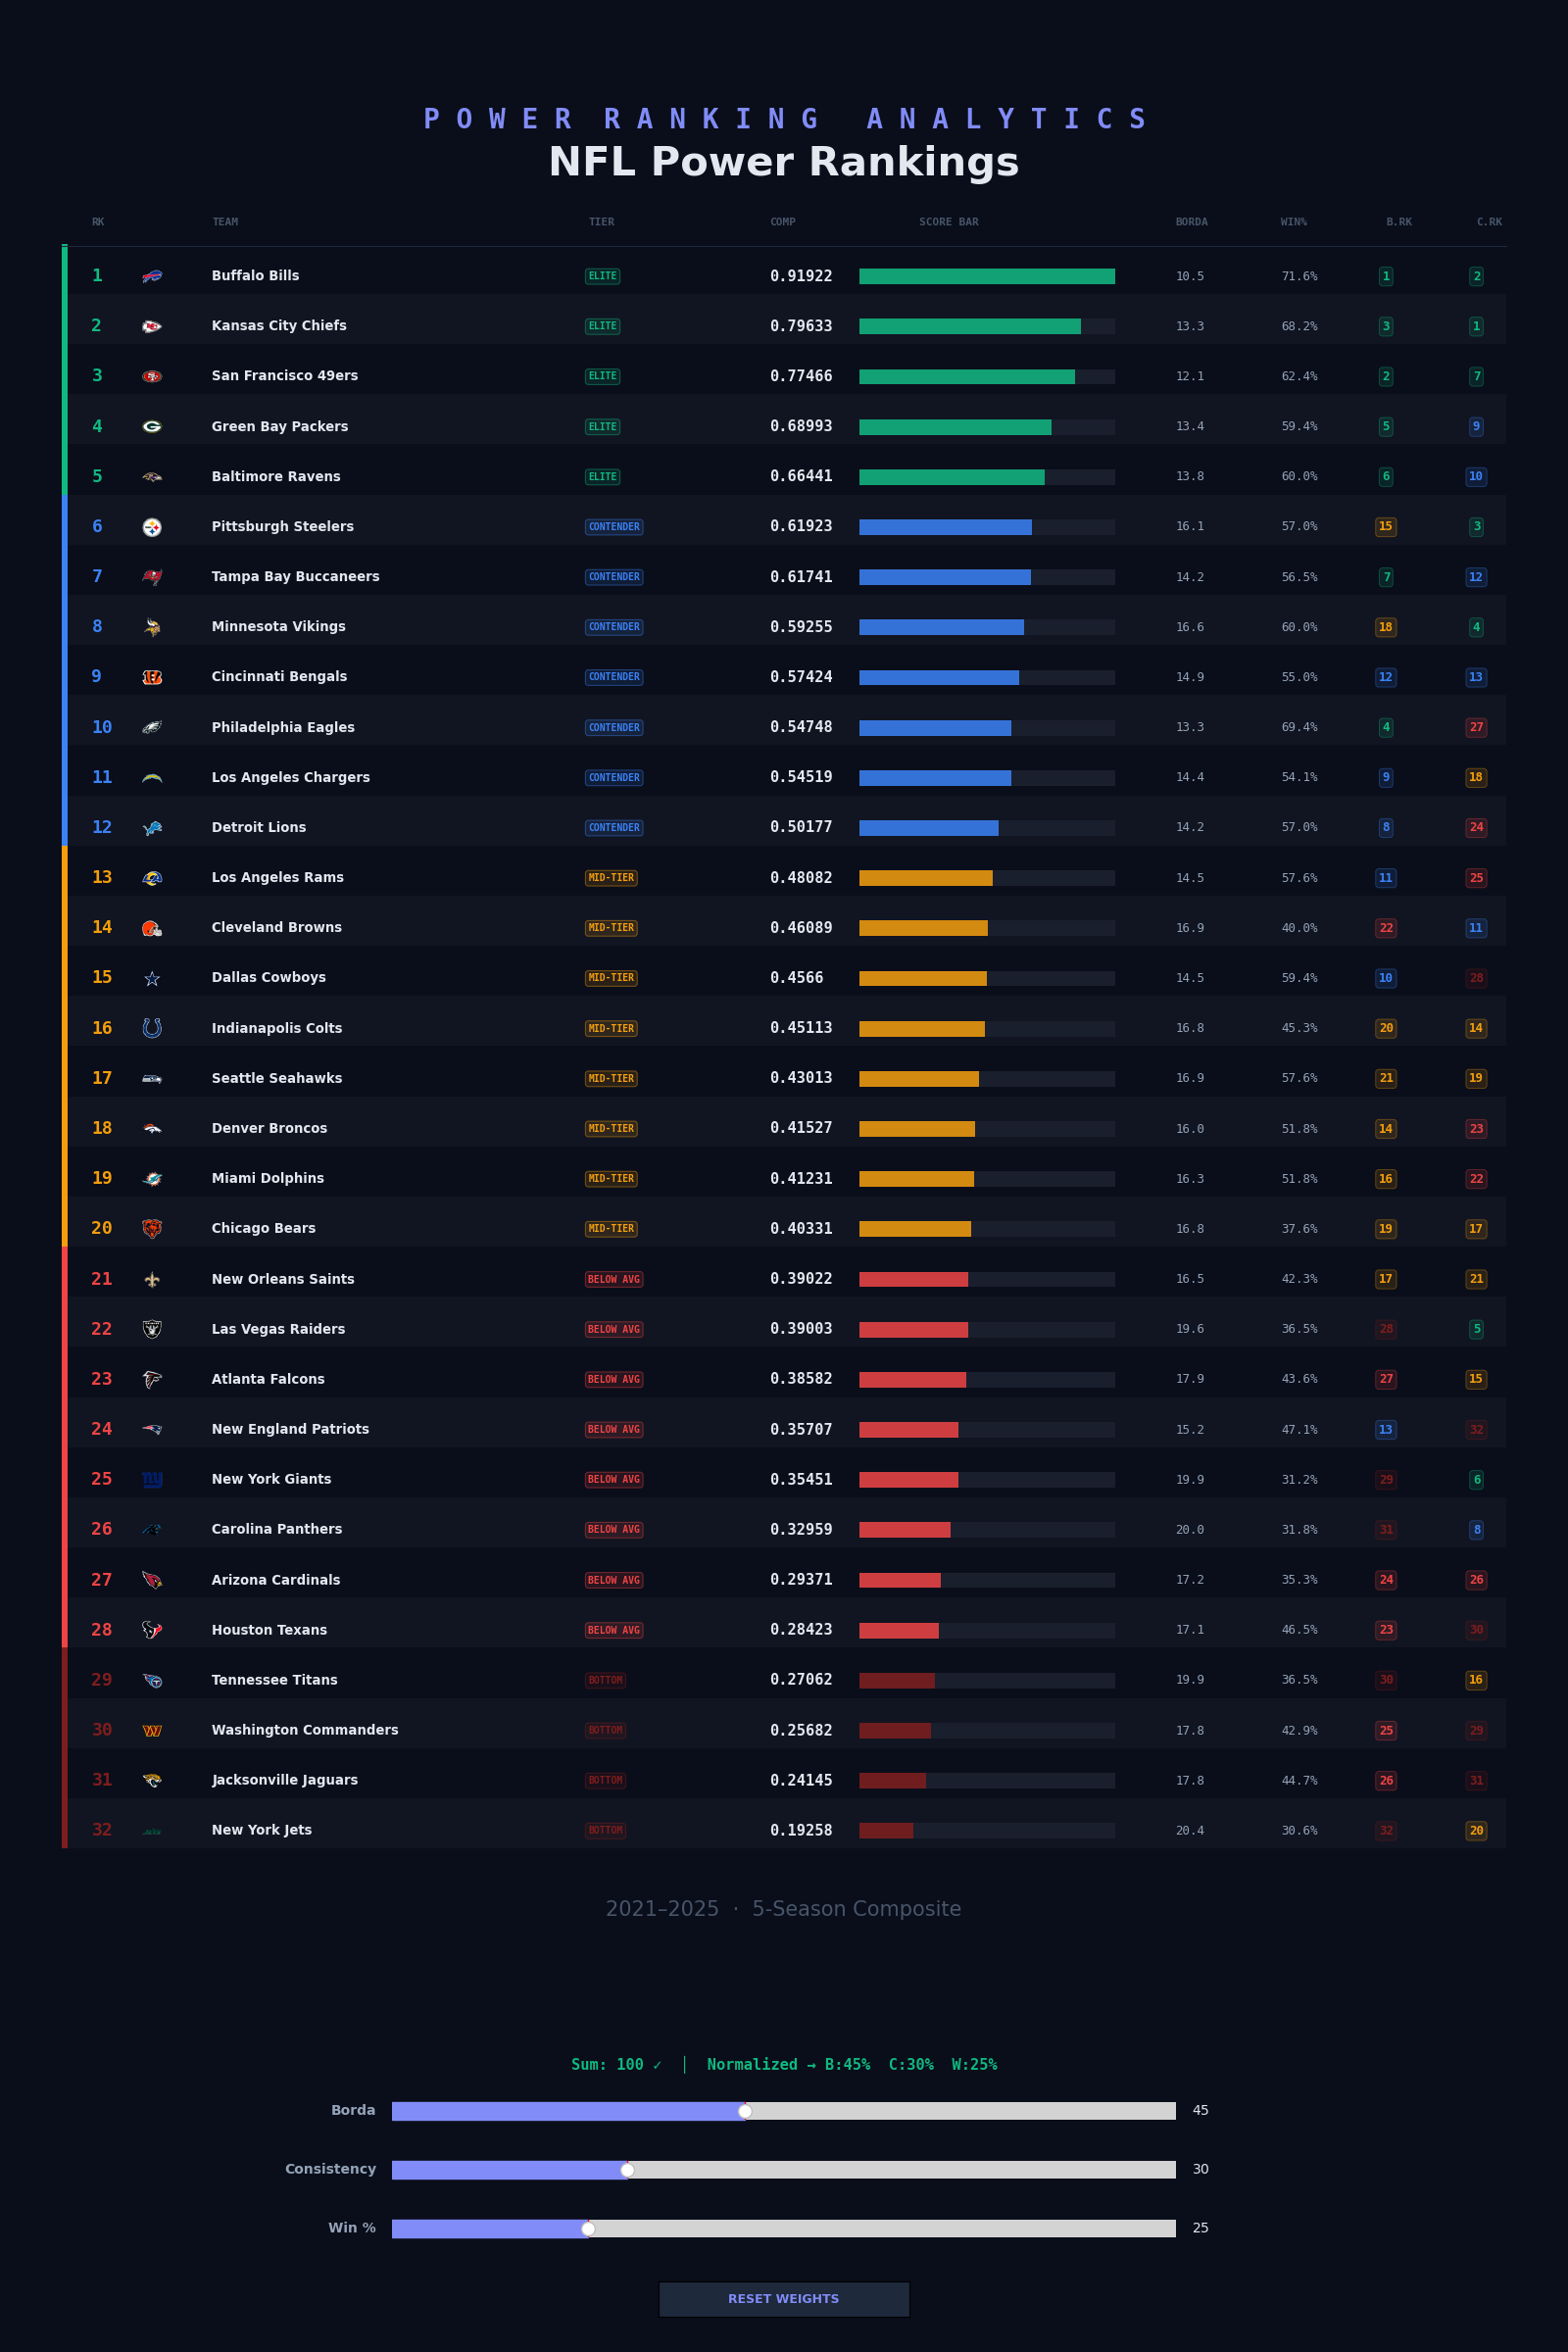

In [56]:
#Goal in this data set was to transform the team BORDA rankings (composite) and between-season SDs into a unified power ranking to view
#how teams had performed over the past 5 seasons and how consistent their outputs were. 
#Using the data above, created hard-coded lists within a dictionary and then used Pandas to create a DataFrame
#Added in team mapping and team hex color codes 
#Used a code block to obtain team images from ESPN 
#Created the composite and tier functions 
#Added in slider bars

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO
import numpy as np

# ── NFL Data ─────────────────────────────────────────────────────────────────
data = {
    'Tm': ['Buffalo Bills','San Francisco 49ers','Kansas City Chiefs','Philadelphia Eagles',
           'Green Bay Packers','Baltimore Ravens','Tampa Bay Buccaneers','Detroit Lions',
           'Los Angeles Chargers','Dallas Cowboys','Los Angeles Rams','Cincinnati Bengals',
           'New England Patriots','Denver Broncos','Pittsburgh Steelers','Miami Dolphins',
           'New Orleans Saints','Minnesota Vikings','Chicago Bears','Indianapolis Colts',
           'Seattle Seahawks','Cleveland Browns','Houston Texans','Arizona Cardinals',
           'Washington Commanders','Jacksonville Jaguars','Atlanta Falcons','Las Vegas Raiders',
           'New York Giants','Tennessee Titans','Carolina Panthers','New York Jets'],
    'Seasons_Played': [5]*32,
    'Avg_W_pct': [71.56,62.36,68.24,69.42,59.42,60.02,56.48,57.04,54.10,59.42,
                  57.64,54.98,47.06,51.78,57.04,51.76,42.34,60.02,37.64,45.30,
                  57.64,40.00,46.46,35.28,42.94,44.68,43.56,36.46,31.16,36.46,31.78,30.58],
    'Avg_Combined_Borda': [10.536,12.140,13.260,13.264,13.412,13.792,14.204,14.224,
                           14.384,14.496,14.504,14.856,15.152,16.044,16.104,16.320,
                           16.500,16.640,16.804,16.812,16.888,16.944,17.140,17.168,
                           17.760,17.768,17.936,19.576,19.852,19.860,20.008,20.400],
    'Overall_Combined_Rank': list(range(1, 33)),
    'Combined_Borda_StdDev': [1.463,2.146,1.138,4.212,2.349,2.429,2.659,3.362,2.861,4.383,
                              3.501,2.666,5.082,3.330,1.610,3.235,3.228,1.630,2.857,2.667,
                              2.919,2.510,4.845,3.779,4.403,4.938,2.750,1.630,1.667,2.791,2.335,3.217],
    'Consistency_Rank': [2,7,1,27,9,10,12,24,18,28,25,13,32,23,3,22,21,4,17,14,19,11,30,26,29,31,15,5,6,16,8,20]
}
df = pd.DataFrame(data)

n_teams = len(df)
min_borda = df['Avg_Combined_Borda'].min()
max_borda = df['Avg_Combined_Borda'].max()
max_consist = df['Consistency_Rank'].max()

# ── ESPN logo abbreviations ──────────────────────────────────────────────────
abbr_map = {
    'Buffalo Bills':'buf','San Francisco 49ers':'sf','Kansas City Chiefs':'kc',
    'Philadelphia Eagles':'phi','Green Bay Packers':'gb','Baltimore Ravens':'bal',
    'Tampa Bay Buccaneers':'tb','Detroit Lions':'det','Los Angeles Chargers':'lac',
    'Dallas Cowboys':'dal','Los Angeles Rams':'lar','Cincinnati Bengals':'cin',
    'New England Patriots':'ne','Denver Broncos':'den','Pittsburgh Steelers':'pit',
    'Miami Dolphins':'mia','New Orleans Saints':'no','Minnesota Vikings':'min',
    'Chicago Bears':'chi','Indianapolis Colts':'ind','Seattle Seahawks':'sea',
    'Cleveland Browns':'cle','Houston Texans':'hou','Arizona Cardinals':'ari',
    'Washington Commanders':'wsh','Jacksonville Jaguars':'jax','Atlanta Falcons':'atl',
    'Las Vegas Raiders':'lv','New York Giants':'nyg','Tennessee Titans':'ten',
    'Carolina Panthers':'car','New York Jets':'nyj'
}

team_colors = {
    'buf':'#00338D','sf':'#AA0000','kc':'#E31837','phi':'#004C54','gb':'#203731',
    'bal':'#241773','tb':'#D50A0A','det':'#0076B6','lac':'#0080C6','dal':'#003594',
    'lar':'#003594','cin':'#FB4F14','ne':'#002244','den':'#FB4F14','pit':'#FFB612',
    'mia':'#008E97','no':'#D3BC8D','min':'#4F2683','chi':'#0B162A','ind':'#002C5F',
    'sea':'#002244','cle':'#311D00','hou':'#03202F','ari':'#97233F','wsh':'#5A1414',
    'jax':'#006778','atl':'#A71930','lv':'#000000','nyg':'#0B2265','ten':'#0C2340',
    'car':'#0085CA','nyj':'#125740'
}

def fetch_logo(abbr, size=28):
    try:
        url = f"https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/{abbr}.png&h=80&w=80"
        resp = requests.get(url, timeout=5)
        img = Image.open(BytesIO(resp.content)).convert("RGBA").resize((size, size), Image.LANCZOS)
        return np.array(img)
    except:
        return None

print("Fetching team logos...")
logos = {abbr: fetch_logo(abbr) for abbr in abbr_map.values()}

# ── Composite + Tier functions ───────────────────────────────────────────────
def compute_composite(row, weights, season_penalty=True):
    norm_borda = 1 - (row['Avg_Combined_Borda'] - min_borda) / (max_borda - min_borda)
    norm_consist = 1 - (row['Consistency_Rank'] - 1) / (max_consist - 1)
    norm_wpct = row['Avg_W_pct'] / 100
    season_factor = min(row['Seasons_Played'] / 3, 1.0) if season_penalty else 1.0
    raw = (norm_borda * weights['borda'] +
           norm_consist * weights['consistency'] +
           norm_wpct * weights['win_pct'])
    return round(raw, 5)

def get_tier(rank, total):
    if rank <= 5:  return ('ELITE', '#10b981')
    if rank <= 12: return ('CONTENDER', '#3b82f6')
    if rank <= 20: return ('MID-TIER', '#f59e0b')
    if rank <= 28: return ('BELOW AVG', '#ef4444')
    return ('BOTTOM', '#7f1d1d')

# ── Build figure ─────────────────────────────────────────────────────────────
# IMPORTANT: Use %matplotlib qt or %matplotlib tk in Jupyter
fig = plt.figure(figsize=(16, 24))
fig.patch.set_facecolor('#0a0e1a')

ax = fig.add_axes([0.02, 0.11, 0.96, 0.82])
ax.set_facecolor('#0a0e1a')
ax.axis('off')

# ── Sliders ──────────────────────────────────────────────────────────────────
slider_color = '#1e293b'
active_color = '#818cf8'

ax_borda   = fig.add_axes([0.25, 0.095, 0.50, 0.015], facecolor=slider_color)
ax_consist = fig.add_axes([0.25, 0.070, 0.50, 0.015], facecolor=slider_color)
ax_wpct    = fig.add_axes([0.25, 0.045, 0.50, 0.015], facecolor=slider_color)
ax_reset   = fig.add_axes([0.42, 0.015, 0.16, 0.015])

# NFL all play 5 seasons, so season weight starts at 0 (no penalty needed)
s_borda   = Slider(ax_borda,   'Borda',       0, 100, valinit=45, valstep=1, color=active_color)
s_consist = Slider(ax_consist, 'Consistency',  0, 100, valinit=30, valstep=1, color=active_color)
s_wpct    = Slider(ax_wpct,    'Win %',        0, 100, valinit=25, valstep=1, color=active_color)

for s in [s_borda, s_consist, s_wpct]:
    s.label.set_color('#94a3b8')
    s.label.set_fontsize(10)
    s.label.set_fontweight('bold')
    s.valtext.set_color('#e2e8f0')
    s.valtext.set_fontsize(10)

reset_btn = Button(ax_reset, 'RESET WEIGHTS', color='#1e293b', hovercolor='#334155')
reset_btn.label.set_color('#818cf8')
reset_btn.label.set_fontsize(9)
reset_btn.label.set_fontweight('bold')

weight_text = fig.text(0.50, 0.120, '', ha='center', fontsize=11,
                        fontweight='bold', fontfamily='monospace')

# ── Update function ──────────────────────────────────────────────────────────
def update(val=None):
    ax.clear()
    ax.set_facecolor('#0a0e1a')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Read + normalize weights
    raw_b, raw_c, raw_w = s_borda.val, s_consist.val, s_wpct.val
    total = raw_b + raw_c + raw_w 

    if total == 0:
        weights = {'borda': 0.25, 'consistency': 0.25, 'win_pct': 0.25}
        total = 100
    else:
        weights = {
            'borda': raw_b / total,
            'consistency': raw_c / total,
            'win_pct': raw_w / total,
        }

    warn = '⚠️' if abs(total - 100) > 0.5 else '✓'
    weight_text.set_text(
        f"Sum: {int(total)} {warn}  │  "
        f"Normalized → B:{weights['borda']:.0%}  C:{weights['consistency']:.0%}  "
        f"W:{weights['win_pct']:.0%}"
    )
    weight_text.set_color('#10b981' if abs(total - 100) < 1 else '#f59e0b')

    # Recompute + sort
    df['Composite'] = df.apply(compute_composite, axis=1, weights=weights)
    ranked = df.sort_values('Composite', ascending=False).reset_index(drop=True)
    ranked['Power_Rank'] = range(1, n_teams + 1)
    max_comp = ranked['Composite'].max()

    # Layout
    row_h = 0.026
    header_y = 0.97
    start_y = header_y - 0.028

    # Title
    ax.text(0.5, 1.03, 'P O W E R  R A N K I N G   A N A L Y T I C S', transform=ax.transAxes,
            ha='center', va='top', fontsize=20, fontweight='bold', color='#818cf8',
            fontfamily='monospace')
    ax.text(0.5, 1.01, 'NFL Power Rankings', transform=ax.transAxes,
            ha='center', va='top', fontsize=30, fontweight='bold', color='#e2e8f0')
    ax.text(0.5, 0.100, '2021–2025  ·  5-Season Composite',
            transform=ax.transAxes, ha='center', va='top', fontsize=15, color='#475569')

    # Column positions
    cols = {'rank': 0.04, 'logo': 0.08, 'team': 0.12, 'tier': 0.37,
            'composite': 0.49, 'bar_start': 0.55, 'bar_end': 0.72,
            'borda': 0.76, 'wpct': 0.83, 'borda_rk': 0.90, 'consist_rk': 0.96}

    # Header
    for x, label in [(cols['rank'], 'RK'), (cols['team'], 'TEAM'), (cols['tier'], 'TIER'),
                     (cols['composite'], 'COMP'), (cols['bar_start'] + 0.04, 'SCORE BAR'),
                     (cols['borda'], 'BORDA'), (cols['wpct'], 'WIN%'),
                     (cols['borda_rk'], 'B.RK'), (cols['consist_rk'], 'C.RK')]:
        ax.text(x, header_y, label, transform=ax.transAxes, fontsize=8,
                fontweight='bold', color='#475569', fontfamily='monospace', va='center')

    ax.plot([0.02, 0.98], [header_y - 0.012, header_y - 0.012],
            transform=ax.transAxes, color='#1e293b', linewidth=0.8)

    # Rows
    for i, (_, row) in enumerate(ranked.iterrows()):
        y = start_y - i * row_h
        tm = row['Tm']
        abbr = abbr_map[tm]
        tc = team_colors[abbr]
        tier_label, tier_color = get_tier(row['Power_Rank'], n_teams)

        # Alternating bg
        if i % 2 == 1:
            r = plt.Rectangle((0.02, y - row_h/2 + 0.004), 0.96, row_h,
                               transform=ax.transAxes, facecolor='#ffffff08', edgecolor='none', zorder=0)
            ax.add_patch(r)

        # Tier accent
        a = plt.Rectangle((0.02, y - row_h/2 + 0.004), 0.004, row_h,
                           transform=ax.transAxes, facecolor=tier_color, edgecolor='none', zorder=1)
        ax.add_patch(a)

        # Rank
        ax.text(cols['rank'], y, str(row['Power_Rank']), transform=ax.transAxes,
                fontsize=13, fontweight='bold', color=tier_color, va='center', fontfamily='monospace')

        # Logo
        logo_arr = logos.get(abbr)
        if logo_arr is not None:
            im = OffsetImage(logo_arr, zoom=0.55)
            ab = AnnotationBbox(im, (cols['logo'], y), xycoords='axes fraction',
                               frameon=False, box_alignment=(0.5, 0.5))
            ax.add_artist(ab)

        # Team name
        ax.text(cols['team'], y, tm, transform=ax.transAxes,
                fontsize=9.5, fontweight='bold', color='#e2e8f0', va='center')

        # Tier badge
        bp = dict(boxstyle='round,pad=0.3', facecolor=tier_color + '22', edgecolor=tier_color + '66', linewidth=0.8)
        ax.text(cols['tier'], y, tier_label, transform=ax.transAxes, fontsize=7,
                fontweight='bold', color=tier_color, va='center', bbox=bp, fontfamily='monospace')

        # Composite
        ax.text(cols['composite'], y, f"{row['Composite']}", transform=ax.transAxes,
                fontsize=11, fontweight='bold', color='#e2e8f0', va='center', fontfamily='monospace')

        # Bar
        bw = (cols['bar_end'] - cols['bar_start']) * (row['Composite'] / max_comp) if max_comp > 0 else 0
        bg = plt.Rectangle((cols['bar_start'], y - 0.004), cols['bar_end'] - cols['bar_start'],
                           0.008, transform=ax.transAxes, facecolor='#1a1f2e', edgecolor='none', zorder=1)
        fl = plt.Rectangle((cols['bar_start'], y - 0.004), bw, 0.008,
                           transform=ax.transAxes, facecolor=tier_color, edgecolor='none', zorder=2, alpha=0.85)
        ax.add_patch(bg)
        ax.add_patch(fl)

        # Borda / Win%
        ax.text(cols['borda'], y, f"{row['Avg_Combined_Borda']:.1f}", transform=ax.transAxes,
                fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')
        ax.text(cols['wpct'], y, f"{row['Avg_W_pct']:.1f}%", transform=ax.transAxes,
                fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')

        # Rank badges
        for cx, v in [(cols['borda_rk'], row['Overall_Combined_Rank']),
                      (cols['consist_rk'], row['Consistency_Rank'])]:
            p = (n_teams - v) / (n_teams - 1)
            bc = '#10b981' if p > 0.8 else '#3b82f6' if p > 0.6 else '#f59e0b' if p > 0.35 else '#ef4444' if p > 0.15 else '#7f1d1d'
            bbp = dict(boxstyle='round,pad=0.25', facecolor=bc + '22', edgecolor=bc + '55', linewidth=0.7)
            ax.text(cx, y, str(int(v)), transform=ax.transAxes, fontsize=9,
                    fontweight='bold', color=bc, va='center', ha='center', bbox=bbp, fontfamily='monospace')

    fig.canvas.draw_idle()

# ── Connect sliders ──────────────────────────────────────────────────────────
s_borda.on_changed(update)
s_consist.on_changed(update)
s_wpct.on_changed(update)


def reset(event):
    s_borda.reset()
    s_consist.reset()
    s_wpct.reset()


reset_btn.on_clicked(reset)

# ── Initial draw ─────────────────────────────────────────────────────────────
update()
plt.show()